In [1]:
# ═══════════════════════════════════════════════════════════════════════
# §0  USER-EDITABLE CONFIGURATION  (single source of truth)
# ═══════════════════════════════════════════════════════════════════════
# Paths (relative to PROJECT_ROOT, resolved automatically below)
RESULTS_DIR_REL     = "results/vae_3channels_beta65_pro"
COVID_TENSOR_REL    = (
    "data/COVID_AAL3_Tensor_v1_AAL3_131ROIs_OMST_GCE_Signed_"
    "GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned/"
    "GLOBAL_TENSOR_from_COVID_AAL3_Tensor_v1_AAL3_131ROIs_OMST_GCE_"
    "Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz"
)
COVID_METADATA_REL  = "data/SubjectsData_AAL3_COVID.csv"
AD_METADATA_REL     = "data/SubjectsData_AAL3_procesado2.csv"

# Analysis options
TARGET_CLF          = "logreg"          # primary classifier for figures
CLASSIFIER_TYPES    = ["logreg"]        # classifiers to include
ENSEMBLE_METHOD     = "mean"            # "mean" or "median"

# Threshold policy settings (§6) — DO NOT hardcode 0.5
# These are derived from ADNI OOF in §6; these are fallback/overrides:
SCREENING_SENS_MIN  = 0.85             # target sensitivity for screening threshold
FIXED_FPR_MAX       = 0.10             # max false-positive rate for specificity threshold
COST_RATIO_FN_FP    = 2.0              # relative cost of FN vs FP

# Reproducibility
SEED_GLOBAL    = 42
SEED_SAMPLING  = 42

# Outputs
SHOW_FIGURES   = True
SAVE_FIGURES   = True
TOP_K_SUBJECTS = 5                     # subjects per selection group

# Bootstrap
N_BOOTSTRAP    = 10_000
ALPHA_CI       = 0.05                  # 95% CI

# COVID → AD Transfer Inference — Paper-Grade Analysis

**Objective**: Apply a β-VAE + classifier pipeline trained on
ADNI (AD vs CN, 5-fold nested CV) to a COVID cohort (N≈194)
and evaluate AD-likeness with clinical, OOD, and mechanistic lenses.

## Scientific questions

| # | Question | Analysis |
|---|----------|----------|
| 1 | Do COVID patients show elevated AD-like connectivity? | Score distribution, ADNI-derived thresholds (§6) |
| 2 | Is "AD-likeness" associated with cognitive decline (MOCA)? | Correlations, regressions (§7) |
| 3 | Are AD-like COVID subjects in-distribution or OOD? | Recon error, Mahalanobis distance (§5) |
| 4 | Is the effect distinct from fatigue or COVID severity? | Multivariate models, partial correlations (§7) |
| 5 | Which connectivity pathways drive AD-likeness? | Signature decomposition by Yeo networks (§8) |

## Notebook sections

| § | Section | Type |
|---|---------|------|
| 0 | Configuration | User-editable |
| 1 | Setup & imports | Infrastructure |
| 2 | Artifact discovery | Data loading |
| 3 | Physics & data integrity | QC |
| 4 | Core inference results | Descriptive |
| 5 | OOD / domain shift diagnostics | Methodological |
| 6 | Threshold policy (ADNI-derived) | **New** |
| 7 | Clinical / neuroscientific validation | **New** |
| 8 | Signature decomposition by networks | **New** |
| 9 | Subject selection for interpretability | Selection |
| F | Outputs index & provenance | Reproducibility |

> **Important**: Scores represent *AD-likeness indices* calibrated on ADNI.
> They are **not** diagnostic probabilities in the COVID domain.

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# §1  SETUP  (imports, PROJECT_ROOT, sys.path)
# ═══════════════════════════════════════════════════════════════════════
import sys, os, warnings, hashlib, datetime, subprocess, json
from pathlib import Path

warnings.filterwarnings("ignore")

# Robust PROJECT_ROOT: walk upwards until pyproject.toml
_cand = Path.cwd()
for _p in [_cand] + list(_cand.parents):
    if (_p / "pyproject.toml").exists():
        PROJECT_ROOT = _p
        break
else:
    PROJECT_ROOT = _cand.parent
    print(f"⚠ pyproject.toml not found; falling back to {PROJECT_ROOT}")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde, mannwhitneyu, kruskal, spearmanr
from statsmodels.stats.multitest import multipletests
import joblib

np.random.seed(SEED_GLOBAL)

# Publication style
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "legend.fontsize": 9, "figure.facecolor": "white",
    "axes.facecolor": "white",
})
sns.set_style("whitegrid")

# Utility: save figure helper
def save_fig(fig, name, close=True):
    if SAVE_FIGURES:
        fig.savefig(FIGURES_DIR / name, bbox_inches="tight")
    if not SHOW_FIGURES and close:
        plt.close(fig)

# Utility: bootstrap CI
def bootstrap_ci(data, stat_func=np.mean, n_boot=N_BOOTSTRAP, ci=1-ALPHA_CI,
                 seed=SEED_GLOBAL):
    rng = np.random.RandomState(seed)
    boots = np.array([stat_func(rng.choice(data, len(data), replace=True))
                      for _ in range(n_boot)])
    lo = np.percentile(boots, 100*(1-ci)/2)
    hi = np.percentile(boots, 100*(1+ci)/2)
    return stat_func(data), lo, hi

# Utility: Cohen's d (pooled)
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    sp = np.sqrt(((n1-1)*np.std(g1,ddof=1)**2 + (n2-1)*np.std(g2,ddof=1)**2) / (n1+n2-2))
    return (np.mean(g1) - np.mean(g2)) / sp if sp > 1e-9 else 0.0

# Utility: rank-biserial r from Mann-Whitney U
def rank_biserial(g1, g2):
    u, _ = mannwhitneyu(g1, g2, alternative="two-sided")
    return 1 - 2*u/(len(g1)*len(g2))

# Utility: Cliff's delta
def cliffs_delta(g1, g2):
    n1, n2 = len(g1), len(g2)
    more = sum((a > b) for a in g1 for b in g2)
    less = sum((a < b) for a in g1 for b in g2)
    return (more - less) / (n1 * n2)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")

PROJECT_ROOT : /home/diego/proyectos/vae_AD
Python       : 3.10.18
NumPy        : 1.26.4
pandas       : 2.2.3


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# §2  ARTIFACT DISCOVERY  (single source of truth for all paths)
# ═══════════════════════════════════════════════════════════════════════
RESULTS_DIR = PROJECT_ROOT / RESULTS_DIR_REL
OUTPUT_DIR  = RESULTS_DIR / "inference_covid_paper_output"
TABLES_DIR  = OUTPUT_DIR / "Tables"
FIGURES_DIR = OUTPUT_DIR / "Figures"
for _d in [TABLES_DIR, FIGURES_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Training config ──────────────────────────────────────────────
rc_path = RESULTS_DIR / "run_config.json"
assert rc_path.exists(), f"run_config.json not found at {rc_path}"
with open(rc_path) as f:
    run_config = json.load(f)
args_cfg        = run_config["args"]
channels_to_use = args_cfg["channels_to_use"]
ch_names_sel    = args_cfg.get("selected_channel_names", [])
n_folds         = int(args_cfg.get("outer_folds", 5))

# ── COVID tensor ─────────────────────────────────────────────────
covid_tp = PROJECT_ROOT / COVID_TENSOR_REL
assert covid_tp.exists(), f"COVID tensor not found: {covid_tp}"
covid_npz    = np.load(covid_tp, allow_pickle=True)
covid_tensor = covid_npz["global_tensor_data"]
covid_ids    = covid_npz["subject_ids"].astype(str)
covid_chs    = list(covid_npz["channel_names"])
N_COVID      = len(covid_ids)

# ── Inference tables (FAIL EARLY if missing) ─────────────────────
REQUIRED_TABLES = [
    "covid_predictions_per_fold.csv",
    "covid_predictions_ensemble.csv",
    "covid_recon_error_per_fold.csv",
    "covid_recon_error_ensemble.csv",
    "covid_latent_distance_per_fold.csv",
    "covid_latent_distance_ensemble.csv",
    "covid_signature_scores.csv",
]
missing = [t for t in REQUIRED_TABLES if not (TABLES_DIR / t).exists()]
if missing:
    cmd = (f"conda run -n vae_ad python "
           f"{PROJECT_ROOT / 'scripts/inference_covid_from_adcn.py'} "
           f"--classifier_types {' '.join(CLASSIFIER_TYPES)}")
    raise FileNotFoundError(
        f"Missing inference tables: {missing}\n"
        f"Generate them with:\n  {cmd}\n"
        f"Then re-run this notebook."
    )

perfold   = pd.read_csv(TABLES_DIR / "covid_predictions_per_fold.csv")
ensemble  = pd.read_csv(TABLES_DIR / "covid_predictions_ensemble.csv")
recon_pf  = pd.read_csv(TABLES_DIR / "covid_recon_error_per_fold.csv")
recon_ens = pd.read_csv(TABLES_DIR / "covid_recon_error_ensemble.csv")
dist_pf   = pd.read_csv(TABLES_DIR / "covid_latent_distance_per_fold.csv")
dist_ens  = pd.read_csv(TABLES_DIR / "covid_latent_distance_ensemble.csv")
sig_df    = pd.read_csv(TABLES_DIR / "covid_signature_scores.csv")

# ── COVID clinical metadata ──────────────────────────────────────
covid_meta_path = PROJECT_ROOT / COVID_METADATA_REL
assert covid_meta_path.exists(), f"COVID metadata not found: {covid_meta_path}"
covid_meta_raw = pd.read_csv(covid_meta_path)
# Join key: predictions use tensor SubjectIDs (CP0001 ...) which match meta["ID"]
covid_meta_raw["_merge_id"] = covid_meta_raw["ID"].astype(str)

# ── ADNI metadata ────────────────────────────────────────────────
ad_meta_path = PROJECT_ROOT / AD_METADATA_REL
ad_meta = pd.read_csv(ad_meta_path) if ad_meta_path.exists() else None

# ── ADNI OOF predictions (for threshold derivation) ──────────────
oof_candidates = sorted(RESULTS_DIR.glob("all_folds_clf_predictions_MULTI_*.csv"))
if oof_candidates:
    adni_oof_all = pd.read_csv(oof_candidates[0])
    print(f"ADNI OOF loaded: {oof_candidates[0].name} ({adni_oof_all.shape[0]} rows)")
else:
    adni_oof_all = None
    print("⚠ No ADNI OOF predictions found. §6 threshold policy will be SKIPPED.")

# ── Consensus edges (for signature decomposition) ────────────────
ce_candidates = sorted(
    (RESULTS_DIR / "interpretability_paper_output" / "tables").glob("consensus_edges_*.csv")
) if (RESULTS_DIR / "interpretability_paper_output" / "tables").exists() else []
if ce_candidates:
    consensus_edges = pd.read_csv(ce_candidates[0])
    print(f"Consensus edges loaded: {ce_candidates[0].name} ({consensus_edges.shape[0]} edges)")
else:
    consensus_edges = None
    print("⚠ No consensus edges table found. §8 decomposition will be SKIPPED.")

# ── Manifest ─────────────────────────────────────────────────────
manifest_path = OUTPUT_DIR / "run_manifest.json"
manifest = json.load(open(manifest_path)) if manifest_path.exists() else {}

# ── Summary ──────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"COVID tensor        : {covid_tensor.shape}")
print(f"COVID metadata      : {covid_meta_raw.shape} (ResearchGroup: {covid_meta_raw['ResearchGroup'].value_counts().to_dict()})")
print(f"Ensemble predictions: {ensemble.shape}")
print(f"Per-fold predictions: {perfold.shape}")
print(f"OOD tables          : recon={recon_ens.shape}, dist={dist_ens.shape}")
print(f"Signature scores    : {sig_df.shape}")
print(f"ADNI OOF            : {'✓' if adni_oof_all is not None else '✗'}")
print(f"Consensus edges     : {'✓' if consensus_edges is not None else '✗'}")
print(f"Channels used       : {ch_names_sel}")
print(f"{'='*60}")

ADNI OOF loaded: all_folds_clf_predictions_MULTI_svm_vaeconvtranspose4l_ld256_beta6.5_normzscore_offdiag_ch3sel_intFCquarter_drop0.15_ln0_outer5x1_scoreroc_auc.csv (366 rows)
Consensus edges loaded: consensus_edges_logreg_integrated_gradients_top50.csv (1026 edges)

COVID tensor        : (194, 7, 131, 131)
COVID metadata      : (214, 20) (ResearchGroup: {'COVID': 168, 'CONTROL': 46})
Ensemble predictions: (194, 9)
Per-fold predictions: (970, 6)
OOD tables          : recon=(194, 3), dist=(194, 3)
Signature scores    : (194, 3)
ADNI OOF            : ✓
Consensus edges     : ✓
Channels used       : ['Pearson_Full_FisherZ_Signed', 'Pearson_OMST_GCE_Signed_Weighted', 'MI_KNN_Symmetric']


## §3 — Phase 0: Physics & Data Integrity

Sanity checks on the COVID tensor before any analysis.
- NaN / Inf, diag zeros, symmetry.
- TR provenance risk.
- Per-channel off-diagonal statistics for selected channels.

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# §3  PHASE 0 — PHYSICS & DATA INTEGRITY
# ═══════════════════════════════════════════════════════════════════════
ct = covid_tensor
off_diag = ~np.eye(ct.shape[-1], dtype=bool)

checks = {
    "Shape":       str(ct.shape),
    "dtype":       str(ct.dtype),
    "NaN count":   int(np.isnan(ct).sum()),
    "Inf count":   int(np.isinf(ct).sum()),
    "Diag max":    float(np.abs(ct[:, :, ~off_diag]).max()),
    "Symmetry δ":  float(np.abs(ct - ct.transpose(0,1,3,2)).max()),
    "TR (s)":      float(covid_npz["tr_seconds"].item()),
    "target_len":  int(covid_npz["target_len_ts"].item()),
    "BP low Hz":   float(covid_npz["filter_low_hz"].item()),
    "BP high Hz":  float(covid_npz["filter_high_hz"].item()),
    "N ROIs":      int(covid_npz["rois_count"].item()),
}
print("Phase 0: Data Integrity\n" + "="*50)
for k, v in checks.items():
    flag = "✓" if k not in ("NaN count","Inf count","Diag max","Symmetry δ") \
                  or float(v) == 0 else ("⚠" if float(v) < 1e-6 else "✗")
    print(f"  {flag} {k:16s}: {v}")

# Per-channel stats (selected channels only)
print(f"\nPer-channel off-diag stats (selected: {channels_to_use}):")
for ch_idx in channels_to_use:
    od = ct[:, ch_idx][:, off_diag]
    print(f"  ch{ch_idx} ({covid_chs[ch_idx][:40]:40s}): "
          f"μ={od.mean():.4f}  σ={od.std():.4f}  "
          f"[{od.min():.4f}, {od.max():.4f}]")

print(f"\n⚠ RISK: TR = {checks['TR (s)']}s was passed as CLI arg during feature "
      f"extraction.\n  It was NOT verified from NIfTI headers. If incorrect, "
      f"bandpass filtering is wrong.")

Phase 0: Data Integrity
  ✓ Shape           : (194, 7, 131, 131)
  ✓ dtype           : float32
  ✓ NaN count       : 0
  ✓ Inf count       : 0
  ✓ Diag max        : 0.0
  ✓ Symmetry δ      : 0.0
  ✓ TR (s)          : 3.0
  ✓ target_len      : 140
  ✓ BP low Hz       : 0.01
  ✓ BP high Hz      : 0.08
  ✓ N ROIs          : 131

Per-channel off-diag stats (selected: [1, 0, 2]):
  ch1 (Pearson_Full_FisherZ_Signed             ): μ=-0.0018  σ=0.7815  [-4.4827, 5.1193]
  ch0 (Pearson_OMST_GCE_Signed_Weighted        ): μ=0.3434  σ=1.2055  [0.0000, 6.1624]
  ch2 (MI_KNN_Symmetric                        ): μ=0.0369  σ=0.7841  [-3.7894, 5.8311]

⚠ RISK: TR = 3.0s was passed as CLI arg during feature extraction.
  It was NOT verified from NIfTI headers. If incorrect, bandpass filtering is wrong.


## §4 — Phase 1: Core Inference Results

Score distributions, cross-fold stability, and reliability metrics.

**Score definition**: The `y_score` is `P(AD)` from the loaded classifier
pipeline. If a calibrated pipeline was available, the score reflects
Platt-scaled / isotonic-calibrated probabilities on ADNI OOF.
In the COVID domain, this is an **AD-likeness index**, not a diagnosis.

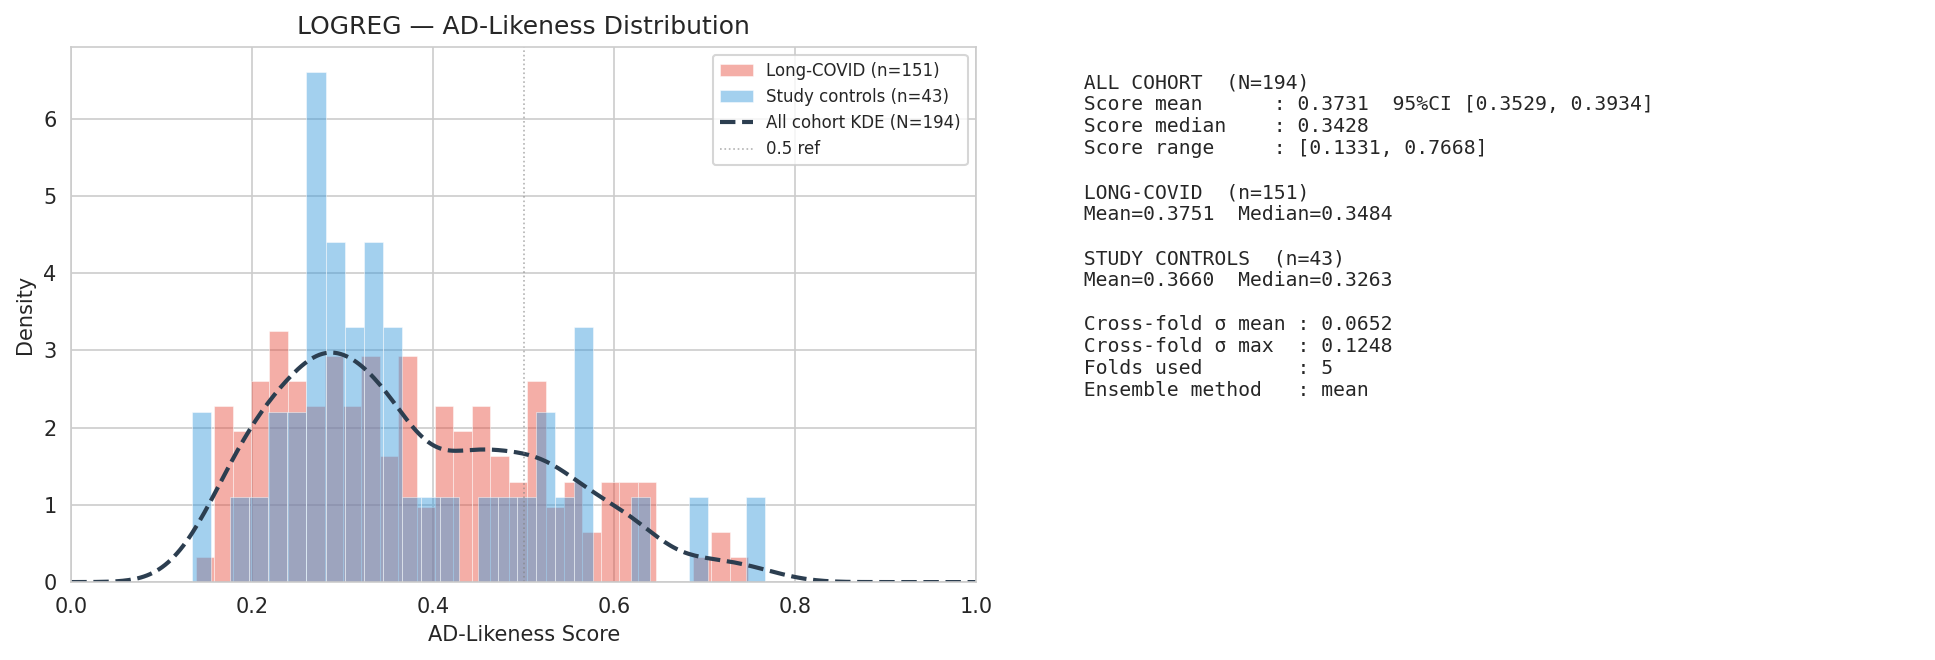

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# §4a  Score distribution (ensemble) — per classifier
#   Split: Long-COVID vs Study controls
# ═══════════════════════════════════════════════════════════════════════

# Merge ResearchGroup for group-aware plotting
_meta_rg = covid_meta_raw[["_merge_id", "ResearchGroup"]].copy()
_meta_rg["ResearchGroup"] = (
    _meta_rg["ResearchGroup"].astype(str).str.strip().str.upper()
)

for clf in CLASSIFIER_TYPES:
    sub = ensemble[ensemble["classifier"] == clf].copy()
    sub = sub.merge(_meta_rg, left_on="SubjectID", right_on="_merge_id", how="left")
    if sub.empty:
        continue
    scores = sub["y_score_ensemble"].values
    scores_covid = sub.loc[sub["ResearchGroup"] == "COVID", "y_score_ensemble"].values
    scores_ctrl  = sub.loc[sub["ResearchGroup"] == "CONTROL", "y_score_ensemble"].values

    # Use ADNI-derived Youden threshold if available, else 0.5 reference
    _t_ref = (threshold_policies.get("Youden", {}).get("threshold", 0.5)
              if "threshold_policies" in dir() and threshold_policies else 0.5)
    _t_label = f"Youden={_t_ref:.3f}" if _t_ref != 0.5 else "0.5 ref"

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # ── Histogram: separate groups + global KDE ──────────────────
    ax = axes[0]
    ax.hist(scores_covid, bins=30, alpha=0.45, color="#E74C3C",
            edgecolor="white", linewidth=0.5, density=True,
            label=f"Long-COVID (n={len(scores_covid)})")
    ax.hist(scores_ctrl, bins=30, alpha=0.45, color="#3498DB",
            edgecolor="white", linewidth=0.5, density=True,
            label=f"Study controls (n={len(scores_ctrl)})")
    # Global KDE overlay
    kde = gaussian_kde(scores, bw_method=0.25)
    xs = np.linspace(0, 1, 300)
    ax.plot(xs, kde(xs), color="#2C3E50", lw=2, ls="--",
            label=f"All cohort KDE (N={len(sub)})")
    ax.set_xlabel("AD-Likeness Score")
    ax.set_ylabel("Density")
    ax.set_title(f"{clf.upper()} — AD-Likeness Distribution")
    ax.set_xlim(0, 1)
    ax.axvline(_t_ref, color="grey", ls=":", lw=0.8, alpha=0.6, label=_t_label)
    ax.legend(fontsize=8)

    # ── Summary stats table ──────────────────────────────────────
    ax = axes[1]
    ax.axis("off")
    mu_s, lo_s, hi_s = bootstrap_ci(scores)
    txt = (
        f"  ALL COHORT  (N={len(sub)})\n"
        f"  Score mean      : {scores.mean():.4f}  95%CI [{lo_s:.4f}, {hi_s:.4f}]\n"
        f"  Score median    : {np.median(scores):.4f}\n"
        f"  Score range     : [{scores.min():.4f}, {scores.max():.4f}]\n\n"
        f"  LONG-COVID  (n={len(scores_covid)})\n"
        f"  Mean={scores_covid.mean():.4f}  Median={np.median(scores_covid):.4f}\n\n"
        f"  STUDY CONTROLS  (n={len(scores_ctrl)})\n"
        f"  Mean={scores_ctrl.mean():.4f}  Median={np.median(scores_ctrl):.4f}\n\n"
        f"  Cross-fold σ mean : {sub['y_score_std'].mean():.4f}\n"
        f"  Cross-fold σ max  : {sub['y_score_std'].max():.4f}\n"
        f"  Folds used        : {sub['n_folds'].iloc[0]}\n"
        f"  Ensemble method   : {ENSEMBLE_METHOD}"
    )
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va="top",
            fontfamily="monospace", fontsize=9.5)

    plt.tight_layout()
    save_fig(fig, f"fig1_score_distribution_{clf}.png", close=False)
    if SHOW_FIGURES: plt.show()
    else: plt.close()

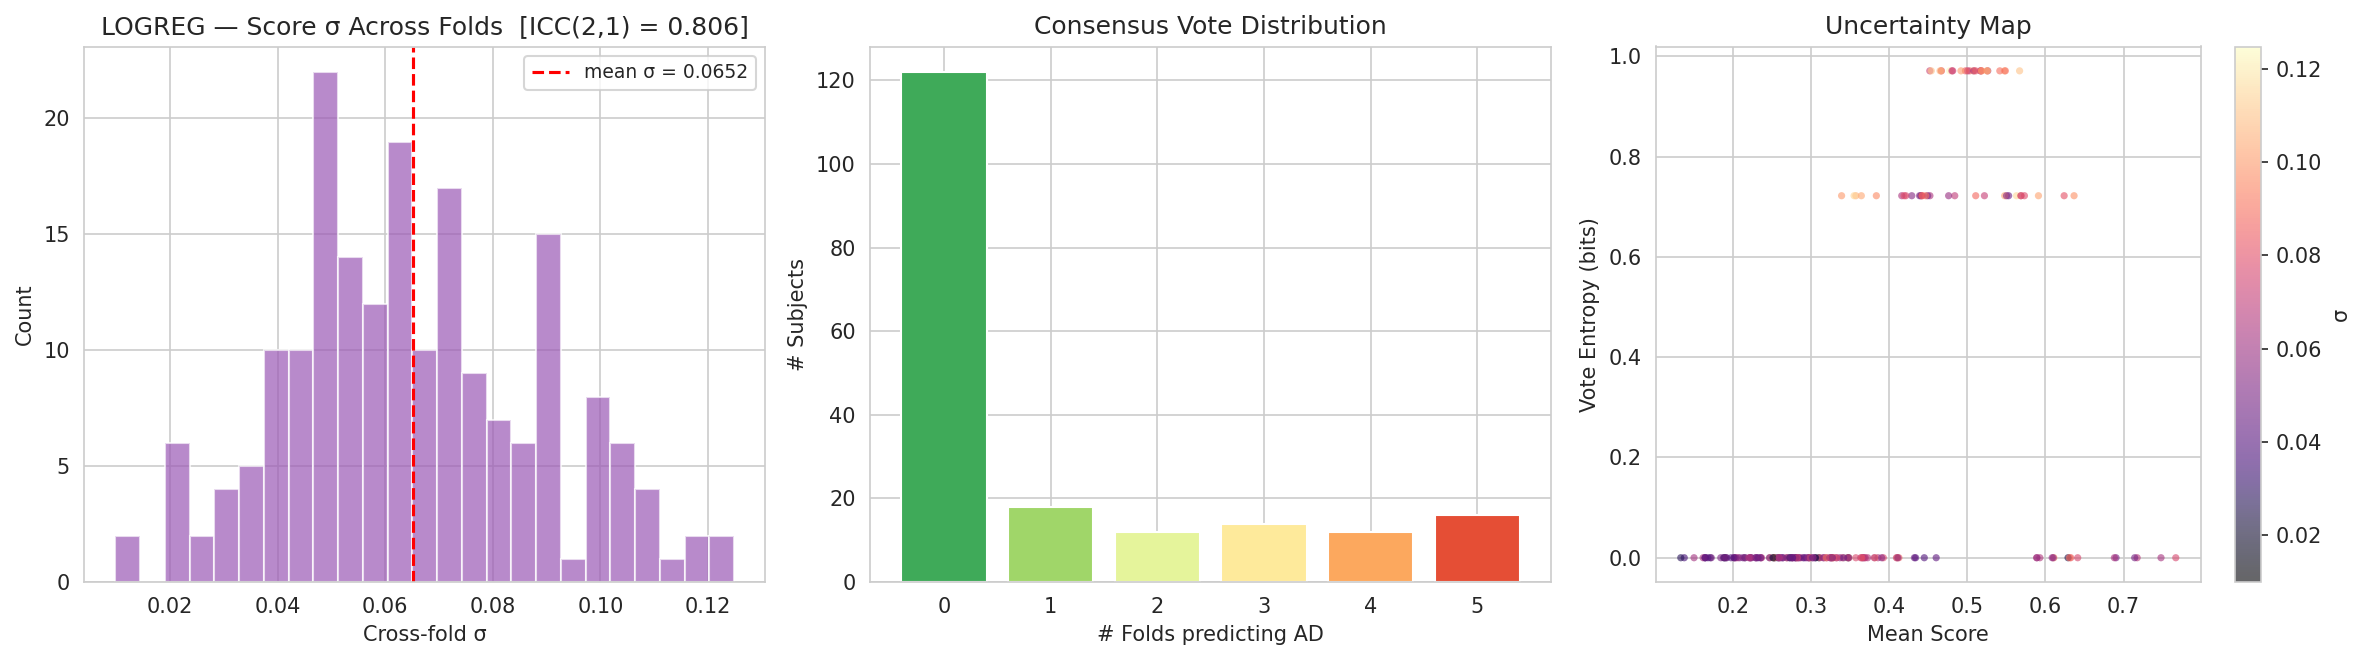


LOGREG Cross-Fold Stability:
  ICC(2,1)  = 0.8058
  Always CN : 122 (62.9%)
  Always AD : 16 (8.2%)
  Mixed     : 56 (28.9%)
  Mean entropy: 0.2418


In [6]:
# ═══════════════════════════════════════════════════════════════════════
# §4b  Cross-fold stability, ICC, entropy
# ═══════════════════════════════════════════════════════════════════════
for clf in CLASSIFIER_TYPES:
    clf_pf = perfold[perfold["classifier"] == clf].copy()

    # ── Per-subject aggregation ──────────────────────────────────
    stab = (clf_pf.groupby("SubjectID")
            .agg(n_folds_ad=("y_pred", "sum"),
                 n_folds=("fold", "nunique"),
                 score_mean=("y_score", "mean"),
                 score_std=("y_score", "std"))
            .reset_index())
    stab["score_std"] = stab["score_std"].fillna(0)

    # Vote entropy: H = -Σ p log p  (binary: p_AD, p_CN)
    def _vote_entropy(n_ad, n_tot):
        p = n_ad / n_tot
        ps = [p, 1-p]
        return -sum(pi * np.log2(pi + 1e-12) for pi in ps if pi > 0)
    stab["vote_entropy"] = stab.apply(
        lambda r: _vote_entropy(r["n_folds_ad"], r["n_folds"]), axis=1)

    # ── ICC(2,1) — two-way random, single measures ──────────────
    # Reshape: subjects × folds
    score_wide = clf_pf.pivot(index="SubjectID", columns="fold", values="y_score")
    score_wide = score_wide.dropna()
    n_subj, k_folds = score_wide.shape
    if n_subj > 10 and k_folds > 1:
        X = score_wide.values
        grand_mean = X.mean()
        ss_total = ((X - grand_mean)**2).sum()
        ss_rows = k_folds * ((X.mean(axis=1) - grand_mean)**2).sum()
        ss_cols = n_subj * ((X.mean(axis=0) - grand_mean)**2).sum()
        ss_error = ss_total - ss_rows - ss_cols
        ms_rows = ss_rows / (n_subj - 1)
        ms_cols = ss_cols / (k_folds - 1)
        ms_error = ss_error / ((n_subj - 1) * (k_folds - 1))
        # ICC(2,1): (MSR - MSE) / (MSR + (k-1)*MSE + k/n*(MSC - MSE))
        icc_21 = (ms_rows - ms_error) / (
            ms_rows + (k_folds - 1)*ms_error +
            k_folds/n_subj * (ms_cols - ms_error))
    else:
        icc_21 = float("nan")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # ── σ distribution ───────────────────────────────────────────
    ax = axes[0]
    ax.hist(stab["score_std"], bins=25, alpha=0.7, color="#9B59B6",
            edgecolor="white")
    ax.axvline(stab["score_std"].mean(), color="red", ls="--",
               label=f"mean σ = {stab['score_std'].mean():.4f}")
    ax.set_xlabel("Cross-fold σ"); ax.set_ylabel("Count")
    ax.set_title(f"{clf.upper()} — Score σ Across Folds  [ICC(2,1) = {icc_21:.3f}]")
    ax.legend(fontsize=9)

    # ── Consensus vote ───────────────────────────────────────────
    ax = axes[1]
    vc = stab["n_folds_ad"].value_counts().sort_index()
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, n_folds+1))
    for v in range(n_folds+1):
        cnt = vc.get(v, 0)
        ax.bar(v, cnt, color=colors_bar[v], edgecolor="white")
    ax.set_xlabel("# Folds predicting AD"); ax.set_ylabel("# Subjects")
    ax.set_title("Consensus Vote Distribution")
    ax.set_xticks(range(n_folds+1))

    # ── Entropy vs score ─────────────────────────────────────────
    ax = axes[2]
    ax.scatter(stab["score_mean"], stab["vote_entropy"],
              c=stab["score_std"], cmap="magma", s=12, alpha=0.6,
              edgecolors="none")
    ax.set_xlabel("Mean Score"); ax.set_ylabel("Vote Entropy (bits)")
    ax.set_title("Uncertainty Map")
    plt.colorbar(ax.collections[0], ax=ax, label="σ")

    plt.tight_layout()
    save_fig(fig, f"fig2_cross_fold_stability_{clf}.png", close=False)
    if SHOW_FIGURES: plt.show()
    else: plt.close()

    # Print
    unan_cn = (stab["n_folds_ad"] == 0).sum()
    unan_ad = (stab["n_folds_ad"] == n_folds).sum()
    mixed = len(stab) - unan_cn - unan_ad
    print(f"\n{clf.upper()} Cross-Fold Stability:")
    print(f"  ICC(2,1)  = {icc_21:.4f}")
    print(f"  Always CN : {unan_cn} ({100*unan_cn/len(stab):.1f}%)")
    print(f"  Always AD : {unan_ad} ({100*unan_ad/len(stab):.1f}%)")
    print(f"  Mixed     : {mixed} ({100*mixed/len(stab):.1f}%)")
    print(f"  Mean entropy: {stab['vote_entropy'].mean():.4f}")

    stab.to_csv(TABLES_DIR / f"covid_fold_stability_{clf}.csv", index=False)

## §5 — Phase 2: OOD / Domain Shift Diagnostics

How "in-distribution" are COVID subjects relative to ADNI?

- **Reconstruction error** (off-diagonal MAE): high = VAE struggles to reconstruct.
- **Latent Mahalanobis distance**: high = far from ADNI train-dev Gaussian.
- **Cross-fold σ**: high = model disagreement across folds.

We define a **2D quadrant** (Score × OOD) to gate interpretations:
- **AD-like & in-distribution** (high score, low OOD) → clinically interesting
- **AD-like & OOD** (high score, high OOD) → requires caution
- **CN-like & in-distribution** → reassuring
- **CN-like & OOD** → domain shift without AD pattern

  → Youden threshold (inline from ADNI OOF): 0.4935


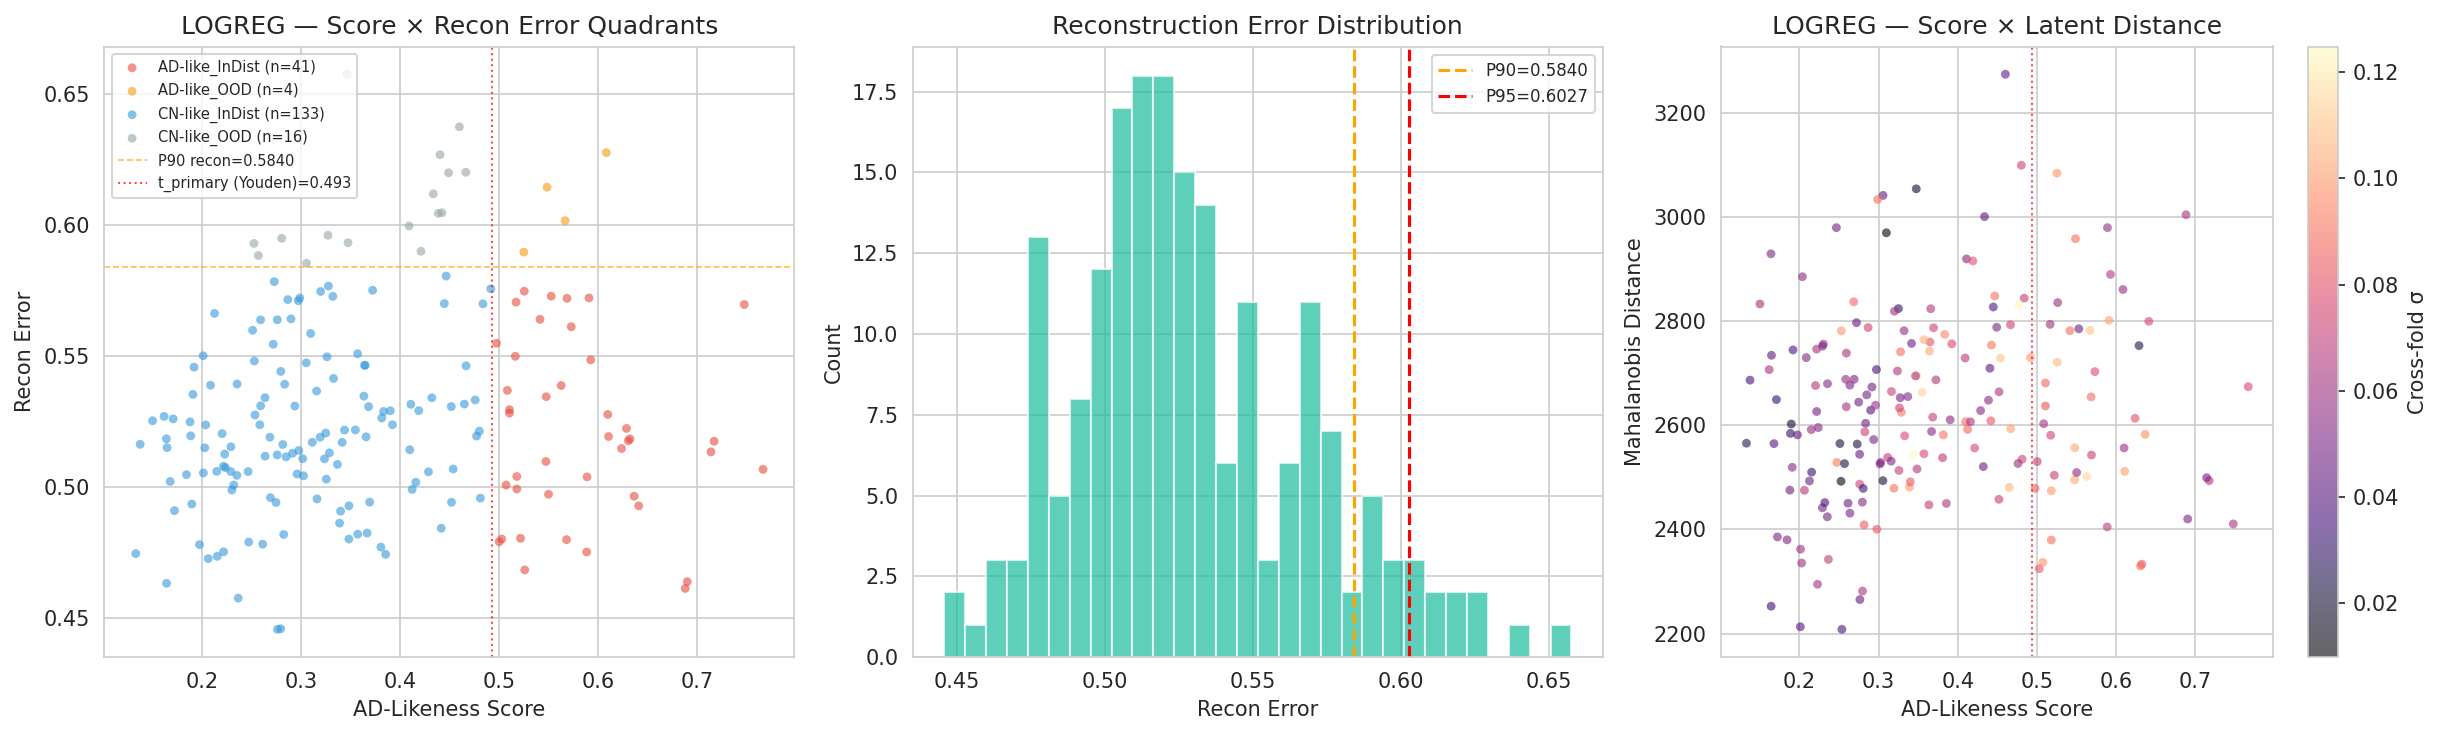


LOGREG OOD Summary (t_primary=0.4935):
  Recon error : 0.5291 ± 0.0398
  Spearman(score, recon) = 0.1459, p = 0.0424
  Latent dist : 2632.2 ± 183.0
  Spearman(score, latent_dist) = 0.1424, p = 0.0477

  Quadrant counts:
    AD-like_InDist      :   41 (21.1%)
    AD-like_OOD         :    4 (2.1%)
    CN-like_InDist      :  133 (68.6%)
    CN-like_OOD         :   16 (8.2%)


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# §5  PHASE 2 — OOD DIAGNOSTICS + QUADRANT LABELS
# ═══════════════════════════════════════════════════════════════════════

# ── Derive t_primary (Youden) from ADNI OOF, or guard if §6 already ran ──
if "threshold_policies" in dir() and threshold_policies:
    t_primary = threshold_policies.get("Youden", {}).get("threshold", 0.5)
    print(f"  → Using Youden from threshold_policies: {t_primary:.4f}")
elif adni_oof_all is not None:
    from sklearn.metrics import roc_curve as _roc_curve
    _oof = adni_oof_all[adni_oof_all["classifier_type"] == TARGET_CLF]
    _fpr, _tpr, _thr = _roc_curve(_oof["y_true"], _oof["y_score_final"])
    t_primary = float(_thr[np.argmax(_tpr - _fpr)])
    print(f"  → Youden threshold (inline from ADNI OOF): {t_primary:.4f}")
else:
    t_primary = 0.5
    print("  ⚠ ADNI OOF unavailable and threshold_policies not computed. Fallback 0.5.")

for clf in CLASSIFIER_TYPES:
    sub = ensemble[ensemble["classifier"] == clf].copy()
    sub = sub.merge(recon_ens, on="SubjectID", how="left")
    sub = sub.merge(dist_ens, on="SubjectID", how="left")
    has_dist = "latent_distance_ensemble" in sub.columns

    # ── OOD threshold: 90th percentile of recon error ────────────
    ood_recon_p90 = sub["recon_error_ensemble"].quantile(0.90)
    ood_recon_p95 = sub["recon_error_ensemble"].quantile(0.95)
    if has_dist:
        ood_dist_p90 = sub["latent_distance_ensemble"].quantile(0.90)

    # ── Quadrant assignment (recon error OOD × ADNI-derived threshold) ─
    _score_col = "y_score_ensemble"
    _ood_col = "recon_error_ensemble"
    sub["ood_flag"] = (sub[_ood_col] >= ood_recon_p90).astype(int)
    sub["quadrant"] = "CN-like_InDist"
    sub.loc[(sub[_score_col] >= t_primary) & (sub["ood_flag"] == 0), "quadrant"] = "AD-like_InDist"
    sub.loc[(sub[_score_col] >= t_primary) & (sub["ood_flag"] == 1), "quadrant"] = "AD-like_OOD"
    sub.loc[(sub[_score_col] < t_primary) & (sub["ood_flag"] == 1), "quadrant"] = "CN-like_OOD"

    # ── Plot ─────────────────────────────────────────────────────
    ncols = 3 if has_dist else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5.5*ncols, 5))

    # Score vs Recon Error
    ax = axes[0]
    quad_colors = {"AD-like_InDist": "#E74C3C", "AD-like_OOD": "#F39C12",
                   "CN-like_InDist": "#3498DB", "CN-like_OOD": "#95A5A6"}
    for q, qc in quad_colors.items():
        mask = sub["quadrant"] == q
        if mask.sum() == 0: continue
        ax.scatter(sub.loc[mask, _score_col], sub.loc[mask, _ood_col],
                  c=qc, s=18, alpha=0.6, label=f"{q} (n={mask.sum()})",
                  edgecolors="none")
    ax.axhline(ood_recon_p90, color="orange", ls="--", lw=0.8, alpha=0.7,
               label=f"P90 recon={ood_recon_p90:.4f}")
    ax.axvline(t_primary, color="red", ls=":", lw=1.0, alpha=0.7,
               label=f"t_primary (Youden)={t_primary:.3f}")
    ax.set_xlabel("AD-Likeness Score"); ax.set_ylabel("Recon Error")
    ax.set_title(f"{clf.upper()} — Score × Recon Error Quadrants")
    ax.legend(fontsize=7, loc="upper left")

    # Recon error distribution
    ax = axes[1]
    ax.hist(sub[_ood_col], bins=30, alpha=0.7, color="#1ABC9C", edgecolor="white")
    ax.axvline(ood_recon_p90, color="orange", ls="--", label=f"P90={ood_recon_p90:.4f}")
    ax.axvline(ood_recon_p95, color="red", ls="--", label=f"P95={ood_recon_p95:.4f}")
    ax.set_xlabel("Recon Error"); ax.set_ylabel("Count")
    ax.set_title("Reconstruction Error Distribution")
    ax.legend(fontsize=8)

    # Score vs Latent Distance
    if has_dist:
        ax = axes[2]
        sc2 = ax.scatter(sub[_score_col], sub["latent_distance_ensemble"],
                        c=sub["y_score_std"], cmap="magma", s=18, alpha=0.6,
                        edgecolors="none")
        plt.colorbar(sc2, ax=ax, label="Cross-fold σ")
        ax.set_xlabel("AD-Likeness Score"); ax.set_ylabel("Mahalanobis Distance")
        ax.set_title(f"{clf.upper()} — Score × Latent Distance")
        ax.axvline(t_primary, color="red", ls=":", lw=1.0, alpha=0.7)

    plt.tight_layout()
    save_fig(fig, f"fig3_ood_diagnostics_{clf}.png", close=False)
    if SHOW_FIGURES: plt.show()
    else: plt.close()

    # Correlations
    r_re, p_re = spearmanr(sub[_score_col], sub[_ood_col])
    print(f"\n{clf.upper()} OOD Summary (t_primary={t_primary:.4f}):")
    print(f"  Recon error : {sub[_ood_col].mean():.4f} ± {sub[_ood_col].std():.4f}")
    print(f"  Spearman(score, recon) = {r_re:.4f}, p = {p_re:.4f}")
    if has_dist:
        r_ld, p_ld = spearmanr(sub[_score_col], sub["latent_distance_ensemble"])
        print(f"  Latent dist : {sub['latent_distance_ensemble'].mean():.1f} ± "
              f"{sub['latent_distance_ensemble'].std():.1f}")
        print(f"  Spearman(score, latent_dist) = {r_ld:.4f}, p = {p_ld:.4f}")
    print(f"\n  Quadrant counts:")
    for q in ["AD-like_InDist","AD-like_OOD","CN-like_InDist","CN-like_OOD"]:
        n = (sub["quadrant"] == q).sum()
        print(f"    {q:20s}: {n:4d} ({100*n/len(sub):.1f}%)")

    # Save quadrant table
    sub.to_csv(TABLES_DIR / f"covid_ood_quadrants_{clf}.csv", index=False)

## §6 — Phase 3: Threshold Policy (ADNI-Derived)

The naïve 0.5 threshold is **not** principled. We derive multiple decision
thresholds from ADNI OOF predictions (out-of-fold, no leakage) and apply
them to the COVID cohort.

| Policy | Definition |
|--------|------------|
| **Youden** | Maximises Sens + Spec - 1 on ADNI OOF |
| **Screening** | Minimum threshold achieving Sens ≥ `SCREENING_SENS_MIN` |
| **Fixed FPR** | Threshold achieving FPR ≤ `FIXED_FPR_MAX` on CN |
| **Cost-based** | Minimises `FN_cost * FN + FP_cost * FP` |

All thresholds are computed **only from ADNI data** and then transferred
to COVID as external cutoffs.

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# §6  PHASE 3 — THRESHOLD POLICY (ADNI-derived, no COVID labels used)
# ═══════════════════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, roc_auc_score

threshold_policies = {}  # name → {"threshold": float, "sens": ..., "spec": ...}

if adni_oof_all is not None:
    adni_oof = adni_oof_all[adni_oof_all["classifier_type"] == TARGET_CLF].copy()
    y_true = adni_oof["y_true"].values
    y_score = adni_oof["y_score_final"].values
    fpr_arr, tpr_arr, thresholds = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)

    # Sensitivity = TPR; Specificity = 1 - FPR
    sens_arr = tpr_arr
    spec_arr = 1 - fpr_arr

    # 1) Youden's J
    j_scores = sens_arr + spec_arr - 1
    idx_youden = np.argmax(j_scores)
    t_youden = thresholds[idx_youden]
    threshold_policies["Youden"] = {
        "threshold": float(t_youden),
        "sens": float(sens_arr[idx_youden]),
        "spec": float(spec_arr[idx_youden]),
    }

    # 2) Screening: min threshold with sens >= target
    mask_screen = sens_arr >= SCREENING_SENS_MIN
    if mask_screen.any():
        # Among thresholds achieving the sensitivity, pick the highest (most specific)
        idx_screen = np.where(mask_screen)[0]
        idx_best = idx_screen[np.argmax(spec_arr[idx_screen])]
        t_screen = thresholds[idx_best]
    else:
        t_screen = thresholds[np.argmax(sens_arr)]
    threshold_policies["Screening"] = {
        "threshold": float(t_screen),
        "sens": float(sens_arr[np.argmin(np.abs(thresholds - t_screen))]),
        "spec": float(spec_arr[np.argmin(np.abs(thresholds - t_screen))]),
    }

    # 3) Fixed FPR: max threshold with FPR <= target
    mask_fpr = fpr_arr <= FIXED_FPR_MAX
    if mask_fpr.any():
        idx_fpr = np.where(mask_fpr)[0]
        idx_best_fpr = idx_fpr[np.argmax(sens_arr[idx_fpr])]
        t_fpr = thresholds[idx_best_fpr]
    else:
        t_fpr = thresholds[-1]
    threshold_policies["FixedFPR"] = {
        "threshold": float(t_fpr),
        "sens": float(sens_arr[np.argmin(np.abs(thresholds - t_fpr))]),
        "spec": float(spec_arr[np.argmin(np.abs(thresholds - t_fpr))]),
    }

    # 4) Cost-based: minimise cost_FN * FN + cost_FP * FP
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    fn_arr = (1 - sens_arr) * n_pos
    fp_arr = fpr_arr * n_neg
    cost_arr = COST_RATIO_FN_FP * fn_arr + fp_arr
    idx_cost = np.argmin(cost_arr)
    t_cost = thresholds[idx_cost]
    threshold_policies["CostBased"] = {
        "threshold": float(t_cost),
        "sens": float(sens_arr[idx_cost]),
        "spec": float(spec_arr[idx_cost]),
    }

    # ── Print summary ────────────────────────────────────────────
    print(f"ADNI OOF: N={len(adni_oof)}, AUC={auc_val:.4f}\n")
    print(f"{'Policy':12s} {'Threshold':>10s} {'Sens':>8s} {'Spec':>8s}")
    print("-" * 42)
    for name, d in threshold_policies.items():
        print(f"{name:12s} {d['threshold']:10.4f} {d['sens']:8.4f} {d['spec']:8.4f}")

    # Save thresholds
    thresh_df = pd.DataFrame([
        {"policy": k, **v} for k, v in threshold_policies.items()
    ])
    thresh_df.to_csv(TABLES_DIR / "adni_derived_thresholds.csv", index=False)
    print(f"\nThresholds saved → {TABLES_DIR / 'adni_derived_thresholds.csv'}")
else:
    print("⚠ ADNI OOF not available. Using 0.5 as fallback.")
    threshold_policies["Fallback_0.5"] = {"threshold": 0.5, "sens": None, "spec": None}

ADNI OOF: N=183, AUC=0.8249

Policy        Threshold     Sens     Spec
------------------------------------------
Youden           0.4935   0.8511   0.6854
Screening        0.4935   0.8511   0.6854
FixedFPR         0.6619   0.4894   0.9101
CostBased        0.4122   0.9362   0.5393

Thresholds saved → /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/inference_covid_paper_output/Tables/adni_derived_thresholds.csv


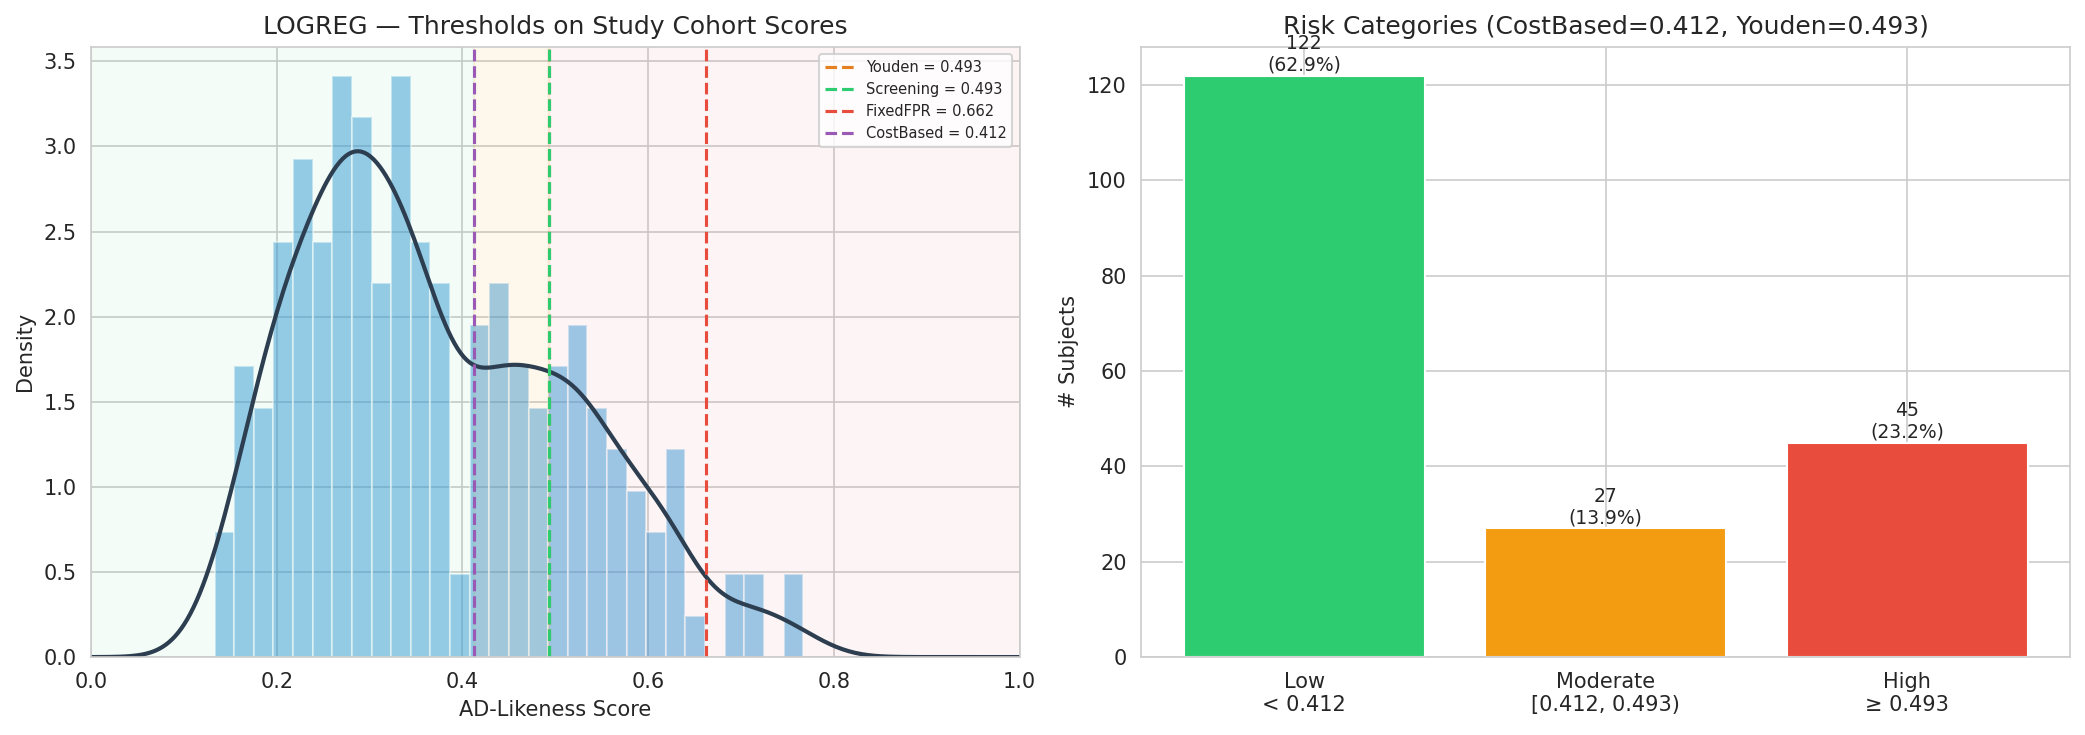


LOGREG — Subjects above each threshold:
  Youden       (t=0.4935):   45 / 194 (23.2%)
  Screening    (t=0.4935):   45 / 194 (23.2%)
  FixedFPR     (t=0.6619):    6 / 194 (3.1%)
  CostBased    (t=0.4122):   72 / 194 (37.1%)

  Risk categories → Low: 122, Moderate: 27, High: 45
  Band boundaries: Low < 0.4122 ≤ Moderate < 0.4935 ≤ High


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# §6b  Apply all thresholds to study cohort + risk categories
#   3-band policy: Low < CostBased ≤ Moderate < Youden ≤ High
# ═══════════════════════════════════════════════════════════════════════
if ensemble is not None and threshold_policies:
    for clf in CLASSIFIER_TYPES:
        sub = ensemble[ensemble["classifier"] == clf].copy()
        scores = sub["y_score_ensemble"].values

        # Apply each threshold
        for name, d in threshold_policies.items():
            t = d["threshold"]
            sub[f"above_{name}"] = (scores >= t).astype(int)

        # Risk categories: 3-band using CostBased (lower) and Youden (upper)
        t_cost_band = threshold_policies.get("CostBased", threshold_policies.get(
            list(threshold_policies.keys())[0]))["threshold"]
        t_youden_band = threshold_policies.get("Youden", threshold_policies.get(
            list(threshold_policies.keys())[0]))["threshold"]

        # Ensure t_lo <= t_hi; swap if needed
        t_lo, t_hi = sorted([t_cost_band, t_youden_band])

        sub["risk_category"] = "Low"
        sub.loc[scores >= t_lo, "risk_category"] = "Moderate"
        sub.loc[scores >= t_hi, "risk_category"] = "High"

        # ── Visualization: score histogram with threshold bands ──
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax = axes[0]
        ax.hist(scores, bins=30, alpha=0.5, color="#3498DB",
                edgecolor="white", density=True)
        kde = gaussian_kde(scores, bw_method=0.25)
        xs = np.linspace(0, 1, 300)
        ax.plot(xs, kde(xs), color="#2C3E50", lw=2)

        # Shade risk bands
        ax.axvspan(0, t_lo, alpha=0.05, color="#2ECC71")
        ax.axvspan(t_lo, t_hi, alpha=0.08, color="#F39C12")
        ax.axvspan(t_hi, 1.0, alpha=0.05, color="#E74C3C")

        # Threshold lines with labels
        th_colors = {"Screening": "#2ECC71", "Youden": "#E67E22",
                     "FixedFPR": "#E74C3C", "CostBased": "#9B59B6",
                     "Fallback_0.5": "grey"}
        for name, d in threshold_policies.items():
            t = d["threshold"]
            c = th_colors.get(name, "black")
            ax.axvline(t, color=c, ls="--", lw=1.5,
                       label=f"{name} = {t:.3f}")
        ax.set_xlabel("AD-Likeness Score"); ax.set_ylabel("Density")
        ax.set_title(f"{clf.upper()} — Thresholds on Study Cohort Scores")
        ax.set_xlim(0, 1)
        ax.legend(fontsize=7, loc="upper right")

        # Risk category bar
        ax = axes[1]
        rc_counts = sub["risk_category"].value_counts()
        cats = ["Low", "Moderate", "High"]
        cat_colors = {"Low": "#2ECC71", "Moderate": "#F39C12", "High": "#E74C3C"}
        for i, cat in enumerate(cats):
            n = rc_counts.get(cat, 0)
            ax.bar(i, n, color=cat_colors[cat], edgecolor="white")
            ax.text(i, n + 1, f"{n}\n({100*n/len(sub):.1f}%)",
                    ha="center", fontsize=9)
        ax.set_xticks(range(len(cats)))
        ax.set_xticklabels([f"Low\n< {t_lo:.3f}",
                            f"Moderate\n[{t_lo:.3f}, {t_hi:.3f})",
                            f"High\n≥ {t_hi:.3f}"])
        ax.set_ylabel("# Subjects")
        ax.set_title(f"Risk Categories (CostBased={t_lo:.3f}, Youden={t_hi:.3f})")

        plt.tight_layout()
        save_fig(fig, f"fig4_threshold_policy_{clf}.png", close=False)
        if SHOW_FIGURES: plt.show()
        else: plt.close()

        # Print summary per threshold
        print(f"\n{clf.upper()} — Subjects above each threshold:")
        for name, d in threshold_policies.items():
            t = d["threshold"]
            n_above = (scores >= t).sum()
            print(f"  {name:12s} (t={t:.4f}): {n_above:4d} / {len(sub)} "
                  f"({100*n_above/len(sub):.1f}%)")
        print(f"\n  Risk categories → Low: {rc_counts.get('Low',0)}, "
              f"Moderate: {rc_counts.get('Moderate',0)}, "
              f"High: {rc_counts.get('High',0)}")
        print(f"  Band boundaries: Low < {t_lo:.4f} ≤ Moderate < {t_hi:.4f} ≤ High")

        sub.to_csv(TABLES_DIR / f"covid_threshold_analysis_{clf}.csv", index=False)

## §7 — Phase 4: Clinical / Neuroscientific Validation

**Primary endpoint**: MOCA (Montreal Cognitive Assessment) and MOCA_perc.

**Secondary**: CategoríaCOVID (severity), CategoriaFAS (fatigue), Recuperado (recovery).

**Covariates**: Age, Sex.

**ID alignment**: The inference outputs use tensor IDs (`CP0001`, etc.) which
match the `ID` column in COVID metadata (NOT the `SubjectID` column).

> Analyses use BH-FDR correction across multiple clinical endpoints.

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# §7a  Merge inference outputs with COVID clinical metadata
# ═══════════════════════════════════════════════════════════════════════
# Join: predictions["SubjectID"] == covid_meta["ID"]
for clf in CLASSIFIER_TYPES:
    sub = ensemble[ensemble["classifier"] == clf].copy()
    sub = sub.merge(recon_ens, on="SubjectID", how="left")
    sub = sub.merge(dist_ens, on="SubjectID", how="left")
    sub = sub.merge(sig_df, on="SubjectID", how="left")

    # Merge clinical data
    clin = sub.merge(covid_meta_raw, left_on="SubjectID", right_on="_merge_id",
                     how="left", suffixes=("", "_meta"))

    # Load threshold analysis if available
    thresh_path = TABLES_DIR / f"covid_threshold_analysis_{clf}.csv"
    if thresh_path.exists():
        thresh_sub = pd.read_csv(thresh_path)
        # Get risk_category
        if "risk_category" in thresh_sub.columns:
            rc_map = thresh_sub.set_index("SubjectID")["risk_category"]
            clin["risk_category"] = clin["SubjectID"].map(rc_map)

    # ── Missingness report ───────────────────────────────────────
    clinical_cols = ["MOCA", "MOCA_perc", "Age", "Sex", "ResearchGroup",
                     "CategoríaCOVID", "CategoriaFAS", "Recuperado", "EQ-VAS",
                     "BMI", "NivelEducativo"]
    # Handle accent variants
    for col in clinical_cols:
        if col not in clin.columns:
            # Try without accent
            alt = col.replace("í", "i").replace("á", "a")
            if alt in clin.columns:
                clin[col] = clin[alt]

    print(f"{clf.upper()} — Clinical merge: {clin.shape}")
    n_matched = clin["_merge_id"].notna().sum()
    print(f"  Matched to metadata: {n_matched} / {len(clin)}")
    print(f"\n  Missingness in matched subjects:")
    avail_cols = [c for c in clinical_cols if c in clin.columns]
    for col in avail_cols:
        n_miss = clin[col].isna().sum()
        print(f"    {col:25s}: {n_miss:3d} / {len(clin)} ({100*n_miss/len(clin):5.1f}%)")

    # ── Define analysis cohorts ──────────────────────────────────
    clin["has_MOCA"] = clin["MOCA"].notna()
    clin["has_clinical"] = clin[["MOCA", "Age", "Sex"]].notna().all(axis=1)
    n_moca = clin["has_MOCA"].sum()
    n_full = clin["has_clinical"].sum()
    print(f"\n  MOCA-complete cohort: {n_moca}")
    print(f"  Full clinical cohort: {n_full}")

    # Save
    clin.to_csv(TABLES_DIR / f"clinical_analysis_cohort_{clf}.csv", index=False)
    print(f"  → saved clinical_analysis_cohort_{clf}.csv")

    # Store for subsequent cells
    _clin_df = clin  # used below

LOGREG — Clinical merge: (194, 36)
  Matched to metadata: 194 / 194

  Missingness in matched subjects:
    MOCA                     :   0 / 194 (  0.0%)
    MOCA_perc                :   0 / 194 (  0.0%)
    Age                      :   0 / 194 (  0.0%)
    Sex                      :   0 / 194 (  0.0%)
    ResearchGroup            :   0 / 194 (  0.0%)
    CategoríaCOVID           :   2 / 194 (  1.0%)
    CategoriaFAS             :   1 / 194 (  0.5%)
    Recuperado               :  25 / 194 ( 12.9%)
    EQ-VAS                   :   0 / 194 (  0.0%)
    BMI                      :   0 / 194 (  0.0%)
    NivelEducativo           :   3 / 194 (  1.5%)

  MOCA-complete cohort: 194
  Full clinical cohort: 194
  → saved clinical_analysis_cohort_logreg.csv


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# §7a.1  COHORT DEFINITIONS + INTEGRITY CHECKS (paper-critical)
# ═══════════════════════════════════════════════════════════════════════

# We assume _clin_df exists from §7a (merged inference + metadata)
clin_all = _clin_df.copy()

# --- Normalize ResearchGroup labels defensively ---
clin_all["ResearchGroup"] = (
    clin_all["ResearchGroup"]
    .astype(str).str.strip().str.upper()
    .replace({"CTRL": "CONTROL", "HC": "CONTROL", "HEALTHY": "CONTROL"})
)

expected_groups = {"COVID", "CONTROL"}
observed_groups = set(clin_all["ResearchGroup"].dropna().unique())
print("Observed ResearchGroup labels:", observed_groups)

# If unexpected labels exist, show them explicitly (do not silently ignore)
bad = observed_groups - expected_groups
if bad:
    print("⚠ Unexpected ResearchGroup labels found:", bad)
    print(clin_all["ResearchGroup"].value_counts(dropna=False))

# --- Define cohorts used throughout the paper ---
clin_covid   = clin_all[clin_all["ResearchGroup"] == "COVID"].copy()
clin_control = clin_all[clin_all["ResearchGroup"] == "CONTROL"].copy()

print(f"\nCohort sizes (within tensor N={len(clin_all)}):")
print(f"  ALL      : {len(clin_all)}")
print(f"  COVID    : {len(clin_covid)}")
print(f"  CONTROL  : {len(clin_control)}")

# --- ID alignment sanity: metadata→tensor restriction ---
# covid_meta_raw has 214 rows, but tensor has 194 IDs. This checks how many metadata rows are actually used.
meta_ids_in_tensor = covid_meta_raw["_merge_id"].isin(clin_all["SubjectID"]).sum()
print(f"\nMetadata rows used (ID in tensor): {meta_ids_in_tensor} / {len(covid_meta_raw)}")

# --- Strong check: counts by ResearchGroup must match after merge ---
vc_from_clin = clin_all["ResearchGroup"].value_counts().to_dict()
print("\nResearchGroup counts in merged cohort:", vc_from_clin)

# Optional cross-check: do ResearchGroup vs CategoríaCOVID make sense?
catcovid_col = None
for c in ["CategoríaCOVID", "CategoriaCOVID"]:
    if c in clin_all.columns:
        catcovid_col = c
        break
if catcovid_col:
    print(f"\nCross-tab: ResearchGroup × {catcovid_col}")
    print(pd.crosstab(clin_all["ResearchGroup"], clin_all[catcovid_col], dropna=False))

Observed ResearchGroup labels: {'CONTROL', 'COVID'}

Cohort sizes (within tensor N=194):
  ALL      : 194
  COVID    : 151
  CONTROL  : 43

Metadata rows used (ID in tensor): 194 / 214

ResearchGroup counts in merged cohort: {'COVID': 151, 'CONTROL': 43}

Cross-tab: ResearchGroup × CategoríaCOVID
CategoríaCOVID  Internación moderada  Internación severa (UCI)  No infectado  \
ResearchGroup                                                                  
CONTROL                            0                         0            22   
COVID                             14                         4             0   

CategoríaCOVID  Paciente ambulatorio  NaN  
ResearchGroup                              
CONTROL                           21    0  
COVID                            131    2  


§7b — Primary cohort: Long-COVID, N(MOCA-complete) = 151

Spearman Correlations — Long-COVID (BH-FDR corrected):

    cohort        predictor  endpoint   n     rho  p_raw   ci_lo  ci_hi  q_fdr  sig_fdr05
Long-COVID y_score_ensemble      MOCA 151 -0.0747 0.3622 -0.2322 0.0869 0.6286      False
Long-COVID y_score_ensemble MOCA_perc 151 -0.0149 0.8558 -0.1766 0.1459 0.8558      False
Long-COVID y_score_ensemble    EQ-VAS 151  0.0662 0.4191 -0.0820 0.2094 0.6286      False
Long-COVID            S_sig      MOCA 151 -0.1365 0.0946 -0.2864 0.0172 0.5274      False
Long-COVID            S_sig MOCA_perc 151 -0.1108 0.1758 -0.2617 0.0452 0.5274      False
Long-COVID            S_sig    EQ-VAS 151 -0.0202 0.8059 -0.1793 0.1362 0.8558      False


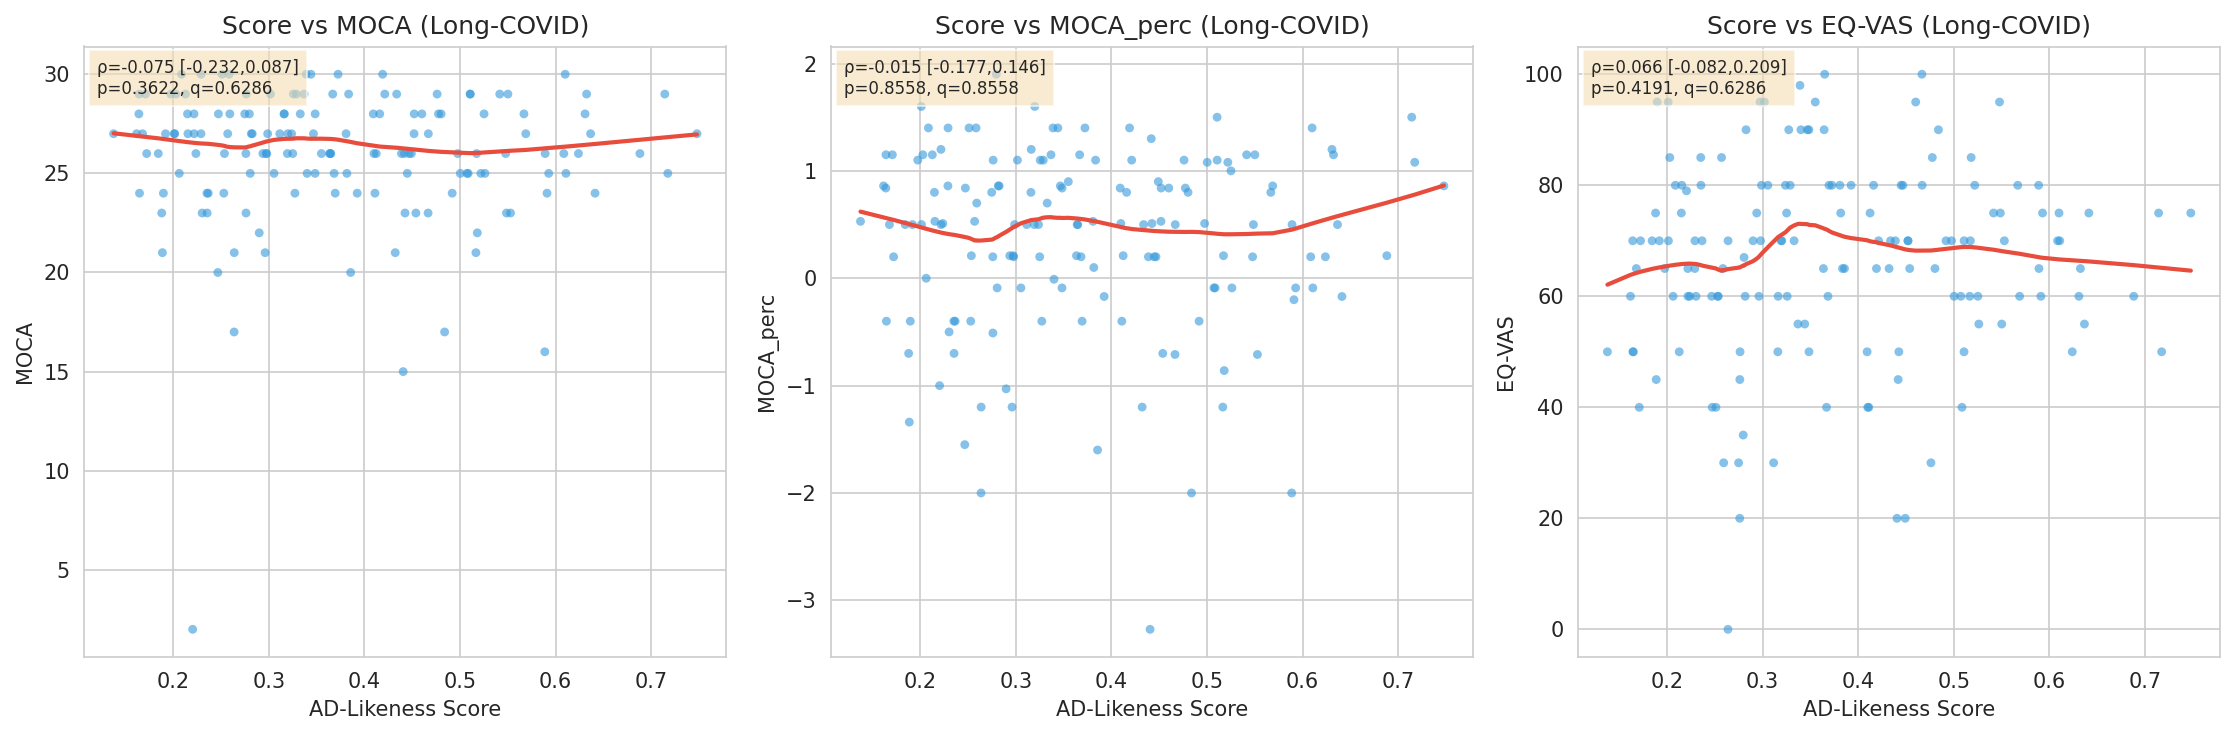

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# §7b  Continuous associations: Score vs MOCA, MOCA_perc, EQ-VAS
#   PRIMARY ANALYSIS: Long-COVID only (clin_covid from §7a.1)
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

# Use the Long-COVID cohort defined in §7a.1 (guard for NameError)
clin = clin_covid.copy() if "clin_covid" in dir() else _clin_df.copy()
clin_complete = clin[clin["has_MOCA"]].copy()
_cohort_label = "Long-COVID" if "clin_covid" in dir() else "All"
print(f"§7b — Primary cohort: {_cohort_label}, N(MOCA-complete) = {len(clin_complete)}")

if len(clin_complete) < 10:
    print("⚠ Too few subjects with MOCA (<10). Skipping clinical associations.")
else:
    # ── Endpoints to test ────────────────────────────────────────
    endpoints = []
    for col in ["MOCA", "MOCA_perc", "EQ-VAS"]:
        if col in clin_complete.columns and clin_complete[col].notna().sum() > 10:
            endpoints.append(col)

    predictors = ["y_score_ensemble"]
    if "S_sig" in clin_complete.columns and clin_complete["S_sig"].notna().sum() > 10:
        predictors.append("S_sig")

    # ── Spearman correlations with bootstrap CI ──────────────────
    results_rows = []
    for pred in predictors:
        for ep in endpoints:
            valid = clin_complete[[pred, ep]].dropna()
            if len(valid) < 10:
                continue
            r, p = spearmanr(valid[pred], valid[ep])
            # Bootstrap CI for Spearman
            rng = np.random.RandomState(SEED_GLOBAL)
            boots = []
            for _ in range(N_BOOTSTRAP):
                idx = rng.choice(len(valid), len(valid), replace=True)
                r_b, _ = spearmanr(valid.iloc[idx][pred], valid.iloc[idx][ep])
                boots.append(r_b)
            lo = np.percentile(boots, 100*ALPHA_CI/2)
            hi = np.percentile(boots, 100*(1-ALPHA_CI/2))
            results_rows.append({
                "cohort": _cohort_label,
                "predictor": pred, "endpoint": ep, "n": len(valid),
                "rho": r, "p_raw": p, "ci_lo": lo, "ci_hi": hi,
            })

    if results_rows:
        corr_df = pd.DataFrame(results_rows)
        # BH-FDR correction
        _, q_vals, _, _ = multipletests(corr_df["p_raw"], method="fdr_bh")
        corr_df["q_fdr"] = q_vals
        corr_df["sig_fdr05"] = q_vals < 0.05

        print(f"\nSpearman Correlations — {_cohort_label} (BH-FDR corrected):\n")
        print(corr_df.to_string(index=False, float_format="{:.4f}".format))
        corr_df.to_csv(TABLES_DIR / "clinical_correlations.csv", index=False)

        # ── Scatter plots ────────────────────────────────────────
        n_ep = len(endpoints)
        fig, axes = plt.subplots(1, n_ep, figsize=(5*n_ep, 5))
        if n_ep == 1: axes = [axes]

        for i, ep in enumerate(endpoints):
            ax = axes[i]
            valid = clin_complete[["y_score_ensemble", ep]].dropna()
            ax.scatter(valid["y_score_ensemble"], valid[ep],
                      c="#3498DB", s=18, alpha=0.6, edgecolors="none")

            # LOWESS trend
            try:
                from statsmodels.nonparametric.smoothers_lowess import lowess
                lw = lowess(valid[ep].values, valid["y_score_ensemble"].values,
                           frac=0.4, return_sorted=True)
                ax.plot(lw[:, 0], lw[:, 1], color="#E74C3C", lw=2, label="LOWESS")
            except ImportError:
                pass

            row = corr_df[(corr_df["predictor"]=="y_score_ensemble") &
                          (corr_df["endpoint"]==ep)]
            if not row.empty:
                r = row.iloc[0]
                ax.text(0.02, 0.98,
                        f"ρ={r['rho']:.3f} [{r['ci_lo']:.3f},{r['ci_hi']:.3f}]\n"
                        f"p={r['p_raw']:.4f}, q={r['q_fdr']:.4f}",
                        transform=ax.transAxes, va="top", fontsize=8,
                        bbox=dict(facecolor="wheat", alpha=0.6))
            ax.set_xlabel("AD-Likeness Score")
            ax.set_ylabel(ep)
            ax.set_title(f"Score vs {ep} ({_cohort_label})")

        plt.tight_layout()
        save_fig(fig, "fig5_clinical_correlations.png", close=False)
        if SHOW_FIGURES: plt.show()
        else: plt.close()

§7c — Primary cohort: Long-COVID, N(MOCA) = 151

Group Comparisons (BH-FDR corrected):

  [Long-COVID] quadrant → MOCA: Kruskal-Wallis, p=0.7388, q=0.9264
    groups: {'CN-like_InDist': 103, 'CN-like_OOD': 13, 'AD-like_InDist': 31, 'AD-like_OOD': 4}
    medians: {'CN-like_InDist': 27.0, 'CN-like_OOD': 26.0, 'AD-like_InDist': 26.0, 'AD-like_OOD': 27.0}
  [Long-COVID] CategoríaCOVID → MOCA: Kruskal-Wallis, p=0.0999, q=0.6995
    groups: {'Paciente ambulatorio': 131, 'Internación severa (UCI)': 4, 'Internación moderada': 14}
    medians: {'Paciente ambulatorio': 27.0, 'Internación severa (UCI)': 23.5, 'Internación moderada': 25.5}
  [Long-COVID] CategoríaCOVID → y_score_ensemble: Kruskal-Wallis, p=0.9264, q=0.9264
    groups: {'Paciente ambulatorio': 131, 'Internación severa (UCI)': 4, 'Internación moderada': 14}
    medians: {'Paciente ambulatorio': 0.3550024960761295, 'Internación severa (UCI)': 0.39456126932762403, 'Internación moderada': 0.353644574543475}
  [Long-COVID] CategoriaFAS 

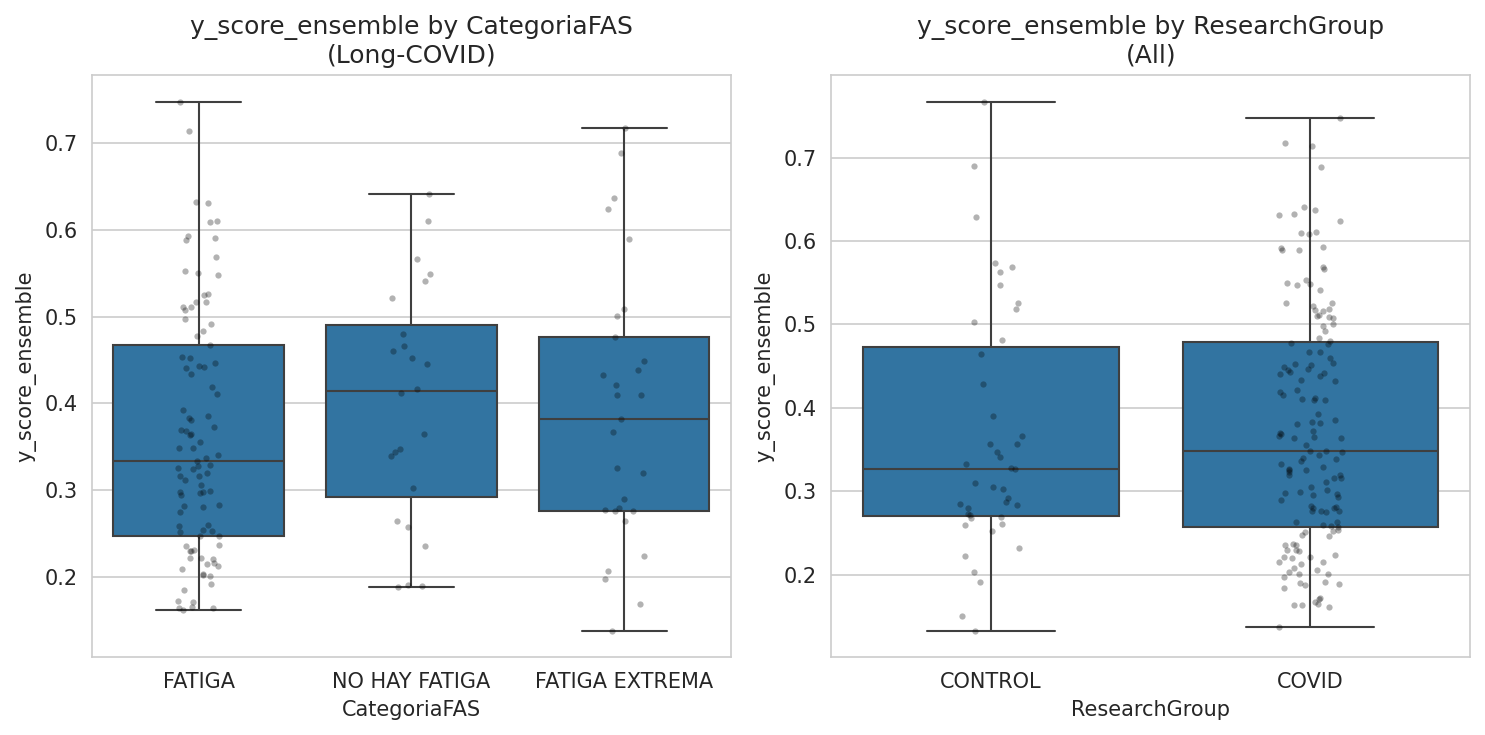

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# §7c  Group comparisons: MOCA by risk category, by OOD quadrant,
#       by ResearchGroup, CategoríaCOVID, CategoriaFAS
#   PRIMARY: Long-COVID only (except ResearchGroup comparisons → all)
# ═══════════════════════════════════════════════════════════════════════

# Primary cohort: Long-COVID from §7a.1
clin = clin_covid.copy() if "clin_covid" in dir() else _clin_df.copy()
# Full cohort for ResearchGroup comparisons
clin_full = clin_all.copy() if "clin_all" in dir() else _clin_df.copy()

# Load quadrant labels
quad_path = TABLES_DIR / f"covid_ood_quadrants_{TARGET_CLF}.csv"
if quad_path.exists():
    quad_df = pd.read_csv(quad_path)[["SubjectID", "quadrant"]]
    clin = clin.merge(quad_df, on="SubjectID", how="left")
    clin_full = clin_full.merge(quad_df, on="SubjectID", how="left")

# Load risk categories from threshold analysis
thresh_path = TABLES_DIR / f"covid_threshold_analysis_{TARGET_CLF}.csv"
if thresh_path.exists():
    tp = pd.read_csv(thresh_path)[["SubjectID", "risk_category"]]
    clin = clin.merge(tp, on="SubjectID", how="left")
    clin_full = clin_full.merge(tp, on="SubjectID", how="left")

clin_moca = clin[clin["MOCA"].notna()].copy()
clin_moca_full = clin_full[clin_full["MOCA"].notna()].copy()
_cohort_label = "Long-COVID" if "clin_covid" in dir() else "All"
print(f"§7c — Primary cohort: {_cohort_label}, N(MOCA) = {len(clin_moca)}")

if len(clin_moca) < 20:
    print("⚠ Too few subjects with MOCA. Skipping group comparisons.")
else:
    # ── Test battery ─────────────────────────────────────────────
    group_tests = []

    # Helper: nonparametric + effect size
    def _group_test(df, group_col, value_col, cohort_tag=""):
        groups = {g: df.loc[df[group_col]==g, value_col].dropna().values
                  for g in df[group_col].dropna().unique()}
        groups = {g: v for g, v in groups.items() if len(v) >= 3}
        if len(groups) < 2:
            return None
        grp_list = list(groups.values())
        if len(groups) == 2:
            g1, g2 = grp_list
            u_stat, p_val = mannwhitneyu(g1, g2, alternative="two-sided")
            d = cohens_d(g1, g2)
            rb = rank_biserial(g1, g2)
            test_name = "Mann-Whitney"
        else:
            h_stat, p_val = kruskal(*grp_list)
            d = np.nan
            rb = np.nan
            test_name = "Kruskal-Wallis"
        return {
            "cohort": cohort_tag,
            "grouping": group_col, "outcome": value_col,
            "n_groups": len(groups), "test": test_name,
            "group_sizes": {g: len(v) for g, v in groups.items()},
            "group_medians": {g: float(np.median(v)) for g, v in groups.items()},
            "p_raw": p_val, "cohens_d": d, "rank_biserial": rb,
        }

    # ── PRIMARY battery: Long-COVID only ─────────────────────────
    test_specs = []
    if "risk_category" in clin_moca.columns:
        test_specs.append(("risk_category", "MOCA"))
        test_specs.append(("risk_category", "MOCA_perc"))
    if "quadrant" in clin_moca.columns:
        test_specs.append(("quadrant", "MOCA"))
    catcovid_col = None
    for c in ["CategoríaCOVID", "CategorîaCOVID", "CategoriaCOVID"]:
        if c in clin_moca.columns:
            catcovid_col = c
            break
    if catcovid_col:
        test_specs.append((catcovid_col, "MOCA"))
        test_specs.append((catcovid_col, "y_score_ensemble"))
    if "CategoriaFAS" in clin_moca.columns:
        test_specs.append(("CategoriaFAS", "MOCA"))
        test_specs.append(("CategoriaFAS", "y_score_ensemble"))

    for grp, out in test_specs:
        if grp in clin_moca.columns and out in clin_moca.columns:
            res = _group_test(clin_moca, grp, out, cohort_tag=_cohort_label)
            if res:
                group_tests.append(res)

    # ── SECONDARY: ResearchGroup comparisons (full cohort) ───────
    if "ResearchGroup" in clin_moca_full.columns:
        for out in ["y_score_ensemble", "MOCA"]:
            if out in clin_moca_full.columns:
                res = _group_test(clin_moca_full, "ResearchGroup", out,
                                  cohort_tag="All (COVID+CONTROL)")
                if res:
                    group_tests.append(res)

    if group_tests:
        gt_df = pd.DataFrame(group_tests)
        _, q_vals, _, _ = multipletests(gt_df["p_raw"], method="fdr_bh")
        gt_df["q_fdr"] = q_vals
        gt_df["sig_fdr05"] = q_vals < 0.05

        print(f"\nGroup Comparisons (BH-FDR corrected):\n")
        for _, row in gt_df.iterrows():
            tag = f"[{row['cohort']}]" if row.get("cohort") else ""
            print(f"  {tag} {row['grouping']} → {row['outcome']}: "
                  f"{row['test']}, p={row['p_raw']:.4f}, q={row['q_fdr']:.4f}"
                  f"{' *' if row['sig_fdr05'] else ''}")
            print(f"    groups: {row['group_sizes']}")
            print(f"    medians: {row['group_medians']}")
            if not np.isnan(row.get("cohens_d", np.nan)):
                print(f"    Cohen's d = {row['cohens_d']:.3f}, "
                      f"rank-biserial = {row['rank_biserial']:.3f}")

        gt_df["group_sizes"] = gt_df["group_sizes"].astype(str)
        gt_df["group_medians"] = gt_df["group_medians"].astype(str)
        gt_df.to_csv(TABLES_DIR / "clinical_group_comparisons.csv", index=False)

    # ── Boxplots (Long-COVID primary) ────────────────────────────
    plot_specs = []
    if "risk_category" in clin_moca.columns:
        plot_specs.append(("risk_category", "MOCA", ["Low","Moderate","High"],
                          {"Low":"#2ECC71","Moderate":"#F39C12","High":"#E74C3C"}))
    if "CategoriaFAS" in clin_moca.columns:
        plot_specs.append(("CategoriaFAS", "y_score_ensemble", None, None))
    # ResearchGroup comparison uses full cohort
    if "ResearchGroup" in clin_moca_full.columns:
        plot_specs.append(("ResearchGroup", "y_score_ensemble", None, None))

    if plot_specs:
        ncols = min(len(plot_specs), 3)
        fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5))
        if ncols == 1: axes = [axes]

        for i, (grp, out, order, pal) in enumerate(plot_specs[:ncols]):
            ax = axes[i]
            # Use full cohort for ResearchGroup, Long-COVID for others
            if grp == "ResearchGroup":
                data = clin_moca_full[[grp, out]].dropna()
                _plot_tag = "All"
            else:
                data = clin_moca[[grp, out]].dropna()
                _plot_tag = _cohort_label
            if order:
                data[grp] = pd.Categorical(data[grp], categories=order, ordered=True)
            sns.boxplot(data=data, x=grp, y=out, ax=ax,
                       palette=pal, showfliers=True)
            sns.stripplot(data=data, x=grp, y=out, ax=ax,
                         color="black", alpha=0.3, size=3, jitter=True)
            ax.set_title(f"{out} by {grp}\n({_plot_tag})")
            if data[grp].nunique() > 3:
                ax.tick_params(axis="x", rotation=30)

        plt.tight_layout()
        save_fig(fig, "fig6_clinical_boxplots.png", close=False)
        if SHOW_FIGURES: plt.show()
        else: plt.close()

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# §7d  Multivariate model: Score ~ MOCA + confounders
#   PRIMARY: Long-COVID only.  Interaction model uses full cohort.
# ═══════════════════════════════════════════════════════════════════════
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Primary: Long-COVID cohort from §7a.1
clin = clin_covid.copy() if "clin_covid" in dir() else _clin_df.copy()
_cohort_label = "Long-COVID" if "clin_covid" in dir() else "All"

# Load risk categories
thresh_path = TABLES_DIR / f"covid_threshold_analysis_{TARGET_CLF}.csv"
if thresh_path.exists():
    tp = pd.read_csv(thresh_path)[["SubjectID", "risk_category"]]
    clin = clin.merge(tp, on="SubjectID", how="left")

# Build regression dataset
reg_cols = ["y_score_ensemble", "MOCA", "Age"]
extra_cols = []
catcovid_col = None
for c in ["CategoríaCOVID", "CategoriaCOVID"]:
    if c in clin.columns:
        catcovid_col = c
        break

if "Sex" in clin.columns:
    clin["Sex_M"] = (clin["Sex"] == "M").astype(float)
    reg_cols.append("Sex_M")

if "CategoriaFAS" in clin.columns:
    fas_map = {"NO HAY FATIGA": 0, "FATIGA": 1, "FATIGA EXTREMA": 2}
    clin["FAS_ordinal"] = clin["CategoriaFAS"].map(fas_map)
    if clin["FAS_ordinal"].notna().sum() > 20:
        reg_cols.append("FAS_ordinal")

if catcovid_col:
    sev_map = {"No infectado": 0, "Paciente ambulatorio": 1,
               "Internación moderada": 2, "Internación severa (UCI)": 3}
    clin["COVID_severity"] = clin[catcovid_col].map(sev_map)
    if clin["COVID_severity"].notna().sum() > 20:
        reg_cols.append("COVID_severity")

if "Recuperado" in clin.columns:
    rec_map = {"completamente": 0, "parcialmente": 1, "No mucho": 2, "para nada": 3}
    clin["Recuperado_ordinal"] = clin["Recuperado"].map(rec_map)
    if clin["Recuperado_ordinal"].notna().sum() > 20:
        reg_cols.append("Recuperado_ordinal")

# Complete cases
avail = [c for c in reg_cols if c in clin.columns]
reg_data = clin[avail].dropna()

if len(reg_data) < 20:
    print(f"⚠ Too few complete cases ({len(reg_data)}). Skipping regression.")
else:
    y_reg = reg_data["y_score_ensemble"]
    X_reg = reg_data.drop(columns=["y_score_ensemble"])

    # Standardize predictors for interpretable coefficients
    X_std = (X_reg - X_reg.mean()) / X_reg.std()
    X_std = sm.add_constant(X_std)

    model = sm.OLS(y_reg, X_std).fit(cov_type="HC3")  # robust SEs

    print(f"OLS Regression ({_cohort_label}): "
          f"y_score_ensemble ~ {' + '.join(X_reg.columns)}")
    print(f"N = {len(reg_data)},  R² = {model.rsquared:.4f},  "
          f"adj-R² = {model.rsquared_adj:.4f}\n")
    print(model.summary2().tables[1].to_string())

    # Bootstrap CI for MOCA coefficient
    if "MOCA" in X_reg.columns:
        rng = np.random.RandomState(SEED_GLOBAL)
        boot_coefs = []
        for _ in range(N_BOOTSTRAP):
            idx = rng.choice(len(reg_data), len(reg_data), replace=True)
            y_b = y_reg.iloc[idx].values
            X_b = X_std.iloc[idx].values
            try:
                coef_b = np.linalg.lstsq(X_b, y_b, rcond=None)[0]
                moca_idx = list(X_std.columns).index("MOCA")
                boot_coefs.append(coef_b[moca_idx])
            except Exception:
                pass
        if boot_coefs:
            lo = np.percentile(boot_coefs, 100*ALPHA_CI/2)
            hi = np.percentile(boot_coefs, 100*(1-ALPHA_CI/2))
            print(f"\nMOCA coefficient bootstrap 95% CI: [{lo:.4f}, {hi:.4f}]")

    # VIF
    vif_data = X_reg.copy()
    vif_data = sm.add_constant(vif_data)
    if vif_data.shape[1] > 2:
        print("\nVariance Inflation Factors:")
        for i, col in enumerate(vif_data.columns):
            if col == "const": continue
            vif = variance_inflation_factor(vif_data.values, i)
            print(f"  {col:25s}: VIF = {vif:.2f}")

    # ── Interaction model: ResearchGroup × MOCA (full cohort) ────
    clin_interact = clin_all.copy() if "clin_all" in dir() else _clin_df.copy()
    if "ResearchGroup" in clin_interact.columns:
        clin_rg = clin_interact[
            clin_interact["ResearchGroup"].astype(str).str.strip().str.upper()
            .isin(["COVID", "CONTROL"])
        ].copy()
        clin_rg["is_COVID"] = (
            clin_rg["ResearchGroup"].astype(str).str.strip().str.upper() == "COVID"
        ).astype(float)
        rg_cols = ["y_score_ensemble", "MOCA", "Age", "is_COVID"]
        if "Sex_M" in clin_rg.columns:
            rg_cols.append("Sex_M")
        elif "Sex" in clin_rg.columns:
            clin_rg["Sex_M"] = (clin_rg["Sex"] == "M").astype(float)
            rg_cols.append("Sex_M")
        rg_data = clin_rg[[c for c in rg_cols if c in clin_rg.columns]].dropna()
        if len(rg_data) > 20 and "MOCA" in rg_data.columns:
            rg_data["MOCA_x_COVID"] = rg_data["MOCA"] * rg_data["is_COVID"]
            y_rg = rg_data["y_score_ensemble"]
            X_rg = rg_data.drop(columns=["y_score_ensemble"])
            X_rg_std = (X_rg - X_rg.mean()) / X_rg.std()
            X_rg_std = sm.add_constant(X_rg_std)
            model_rg = sm.OLS(y_rg, X_rg_std).fit(cov_type="HC3")
            print(f"\n--- Interaction model (full cohort): "
                  f"Score ~ MOCA × ResearchGroup + confounders ---")
            print(f"N = {len(rg_data)}, R² = {model_rg.rsquared:.4f}")
            int_row = model_rg.summary2().tables[1]
            if "MOCA_x_COVID" in int_row.index:
                r = int_row.loc["MOCA_x_COVID"]
                p_col = "P>|z|" if "P>|z|" in int_row.columns else "P>|t|"
                print(f"MOCA × COVID interaction: β={r['Coef.']:.4f}, "
                      f"p={r[p_col]:.4f}")

OLS Regression (Long-COVID): y_score_ensemble ~ MOCA + Age + Sex_M + FAS_ordinal + COVID_severity + Recuperado_ordinal
N = 145,  R² = 0.0284,  adj-R² = -0.0138

                       Coef.  Std.Err.          z          P>|z|    [0.025    0.975]
const               0.372932  0.012467  29.914294  1.282663e-196  0.348498  0.397367
MOCA                0.000055  0.016811   0.003270   9.973910e-01 -0.032894  0.033004
Age                -0.003213  0.013666  -0.235089   8.141393e-01 -0.029998  0.023573
Sex_M               0.020865  0.014348   1.454191   1.458933e-01 -0.007257  0.048987
FAS_ordinal         0.006573  0.014022   0.468756   6.392443e-01 -0.020910  0.034055
COVID_severity      0.001879  0.013782   0.136370   8.915286e-01 -0.025133  0.028892
Recuperado_ordinal -0.012895  0.013254  -0.972883   3.306115e-01 -0.038873  0.013083

MOCA coefficient bootstrap 95% CI: [-0.0331, 0.0201]

Variance Inflation Factors:
  MOCA                     : VIF = 1.02
  Age                      : VIF = 1

## §8 — Phase 5: AD Signature Score & Network Decomposition

The AD "signature score" $S_\text{sig} = \sum_{e} w_e \cdot z_e$ aggregates
consensus edges from the interpretability pipeline.

We decompose $S_\text{sig}$ by **Yeo-17 network pairs** to identify which
inter-network pathways contribute most to AD-likeness in COVID.

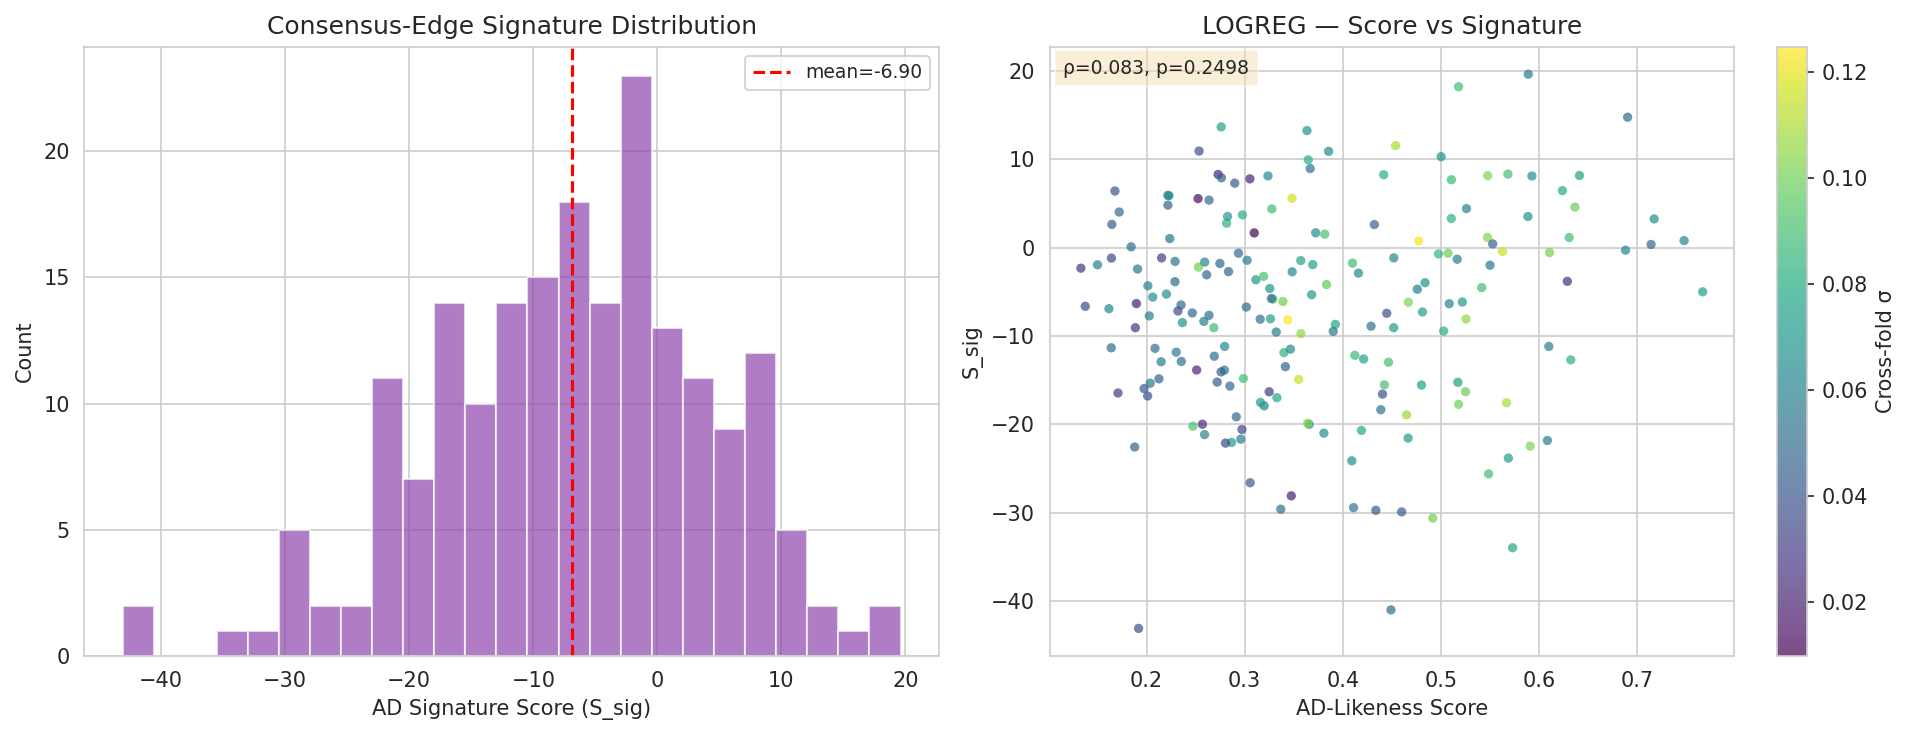

LOGREG Signature: mean=-6.8960 ± 11.2546
  ρ(score, S_sig) = 0.0830, p = 0.2498
  ρ(S_sig, MOCA) = -0.1365, p = 0.0946


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# §8a  Signature score analysis + Score vs S_sig
# ═══════════════════════════════════════════════════════════════════════
if sig_df is not None:
    for clf in CLASSIFIER_TYPES:
        sub = ensemble[ensemble["classifier"] == clf].copy()
        sub = sub.merge(sig_df, on="SubjectID", how="left")

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # Distribution
        ax = axes[0]
        ax.hist(sub["S_sig"].dropna(), bins=25, alpha=0.7, color="#8E44AD",
                edgecolor="white")
        mu_sig = sub["S_sig"].mean()
        ax.axvline(mu_sig, color="red", ls="--", label=f"mean={mu_sig:.2f}")
        ax.set_xlabel("AD Signature Score (S_sig)")
        ax.set_ylabel("Count")
        ax.set_title("Consensus-Edge Signature Distribution")
        ax.legend()

        # Score vs S_sig
        ax = axes[1]
        valid = sub.dropna(subset=["y_score_ensemble", "S_sig"])
        sc = ax.scatter(valid["y_score_ensemble"], valid["S_sig"],
                       c=valid["y_score_std"], cmap="viridis",
                       s=20, alpha=0.7, edgecolors="none")
        plt.colorbar(sc, ax=ax, label="Cross-fold σ")
        r_sig, p_sig = spearmanr(valid["y_score_ensemble"], valid["S_sig"])
        ax.text(0.02, 0.98, f"ρ={r_sig:.3f}, p={p_sig:.4f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(facecolor="wheat", alpha=0.5))
        ax.set_xlabel("AD-Likeness Score")
        ax.set_ylabel("S_sig")
        ax.set_title(f"{clf.upper()} — Score vs Signature")

        plt.tight_layout()
        save_fig(fig, f"fig7_signature_score_{clf}.png", close=False)
        if SHOW_FIGURES: plt.show()
        else: plt.close()

        print(f"{clf.upper()} Signature: mean={mu_sig:.4f} ± {sub['S_sig'].std():.4f}")
        print(f"  ρ(score, S_sig) = {r_sig:.4f}, p = {p_sig:.4f}")

        # S_sig vs MOCA (if clinical data available)
        clin_path = TABLES_DIR / f"clinical_analysis_cohort_{clf}.csv"
        if clin_path.exists():
            #c = pd.read_csv(clin_path)
            c = clin_covid.copy()
            if "MOCA" in c.columns and "S_sig" in c.columns:
                v = c[["S_sig", "MOCA"]].dropna()
                if len(v) > 10:
                    r_m, p_m = spearmanr(v["S_sig"], v["MOCA"])
                    print(f"  ρ(S_sig, MOCA) = {r_m:.4f}, p = {p_m:.4f}")
else:
    print("⚠ No signature scores available. Skipping §8a.")

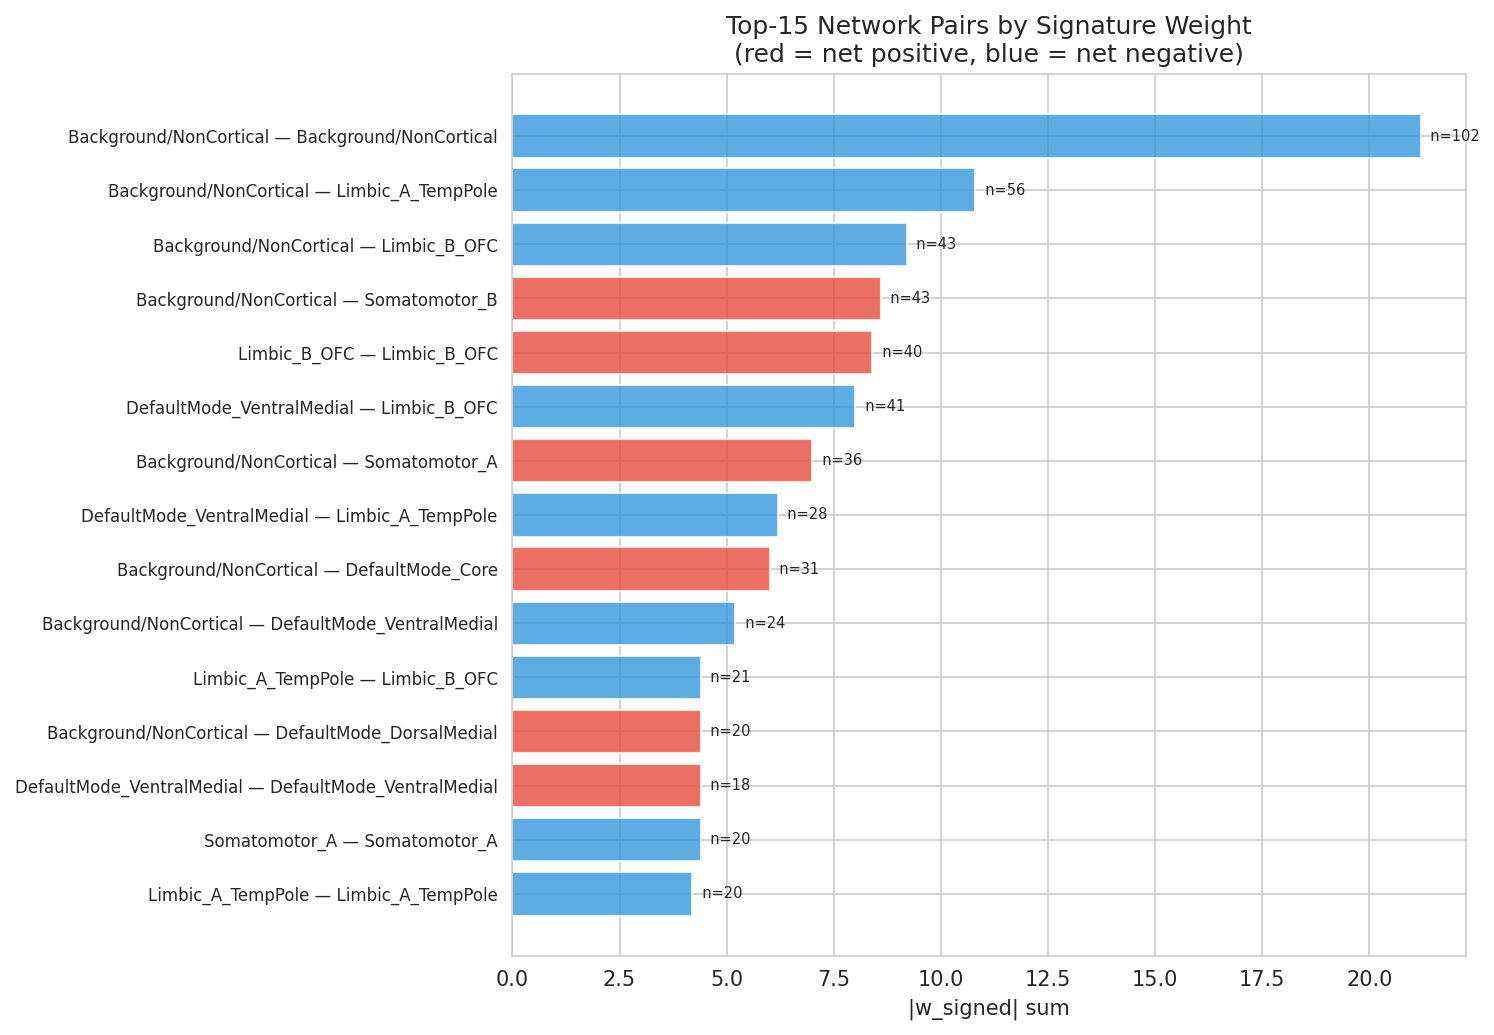

Network pairs with consensus edges: 111

Top-5 by |w_signed| sum:
  Background/NonCortical — Background/NonCortical    n=102  |w|=21.2000  Σw=-5.6000
  Background/NonCortical — Limbic_A_TempPole         n= 56  |w|=10.8000  Σw=-1.6000
  Background/NonCortical — Limbic_B_OFC              n= 43  |w|=9.2000  Σw=-3.6000
  Background/NonCortical — Somatomotor_B             n= 43  |w|=8.6000  Σw=+4.6000
  Limbic_B_OFC — Limbic_B_OFC                        n= 40  |w|=8.4000  Σw=+3.2000


In [16]:
# ═══════════════════════════════════════════════════════════════════════
# §8b  Network-pair decomposition of S_sig
# ═══════════════════════════════════════════════════════════════════════
if consensus_edges is not None and "src_Yeo17_Network" in consensus_edges.columns:
    ce = consensus_edges.copy()

    # Aggregate w_signed by network pair
    ce["net_pair"] = ce.apply(
        lambda r: tuple(sorted([r["src_Yeo17_Network"], r["dst_Yeo17_Network"]])),
        axis=1)
    ce["net_pair_str"] = ce["net_pair"].apply(lambda x: f"{x[0]} — {x[1]}")

    net_agg = (ce.groupby("net_pair_str")
               .agg(n_edges=("w_signed", "count"),
                    w_abs_sum=("w_signed", lambda x: np.abs(x).sum()),
                    w_signed_sum=("w_signed", "sum"),
                    mean_abs_attr=("mean_abs_topk", "mean"))
               .reset_index()
               .sort_values("w_abs_sum", ascending=False))

    # Top-15 network pairs
    top_net = net_agg.head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_net = ["#E74C3C" if v > 0 else "#3498DB"
                  for v in top_net["w_signed_sum"]]
    ax.barh(range(len(top_net)), top_net["w_abs_sum"], color=colors_net, alpha=0.8)
    ax.set_yticks(range(len(top_net)))
    ax.set_yticklabels(top_net["net_pair_str"], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("|w_signed| sum")
    ax.set_title("Top-15 Network Pairs by Signature Weight\n"
                 "(red = net positive, blue = net negative)")

    # Annotation: edge count
    for i, (_, row) in enumerate(top_net.iterrows()):
        ax.text(row["w_abs_sum"] + 0.01, i,
                f"  n={int(row['n_edges'])}", va="center", fontsize=7)

    plt.tight_layout()
    save_fig(fig, "fig8_network_decomposition.png", close=False)
    if SHOW_FIGURES: plt.show()
    else: plt.close()

    print(f"Network pairs with consensus edges: {len(net_agg)}")
    print(f"\nTop-5 by |w_signed| sum:")
    for _, r in net_agg.head(5).iterrows():
        print(f"  {r['net_pair_str']:50s} n={int(r['n_edges']):3d}  "
              f"|w|={r['w_abs_sum']:.4f}  Σw={r['w_signed_sum']:+.4f}")

    net_agg.to_csv(TABLES_DIR / "signature_network_decomposition.csv", index=False)
else:
    if consensus_edges is None:
        print("⚠ No consensus edges. Skipping network decomposition.")
    else:
        print("⚠ No Yeo17 network labels in consensus edges. SKIPPED.")

## §9 — Subject Selection for Interpretability

Deterministic selection of clinically extreme, complete-data subjects:
- **AD-like & in-distribution**: high score + low recon error
- **AD-like & OOD**: high score + high recon error
- **CN-like boundary**: below threshold but near boundary

With clinical annotation (MOCA, fatigue, severity) included where available.


LOGREG — AD_inlier (threshold=0.4935):
SubjectID  y_score_ensemble  y_score_std  recon_error_ensemble     S_sig  latent_distance_ensemble
   CP0035          0.688209     0.063497              0.461427 -0.289233               3004.109188
   CP0002          0.690360     0.050272              0.463988 14.747392               2420.041928
   CP0192          0.526118     0.060682              0.468487  4.409704               2835.410072
   CP0044          0.588697     0.068950              0.475328  3.516083               2404.919844
   CP0108          0.500272     0.070055              0.479238 10.281664               2530.287768

LOGREG — AD_outlier (threshold=0.4935):
SubjectID  y_score_ensemble  y_score_std  recon_error_ensemble      S_sig  latent_distance_ensemble
   CP0238          0.608567     0.057074              0.627696 -21.818652               2860.568783
   CP0142          0.548626     0.089616              0.614499 -25.589508               2958.141113
   CP0042          0.5668

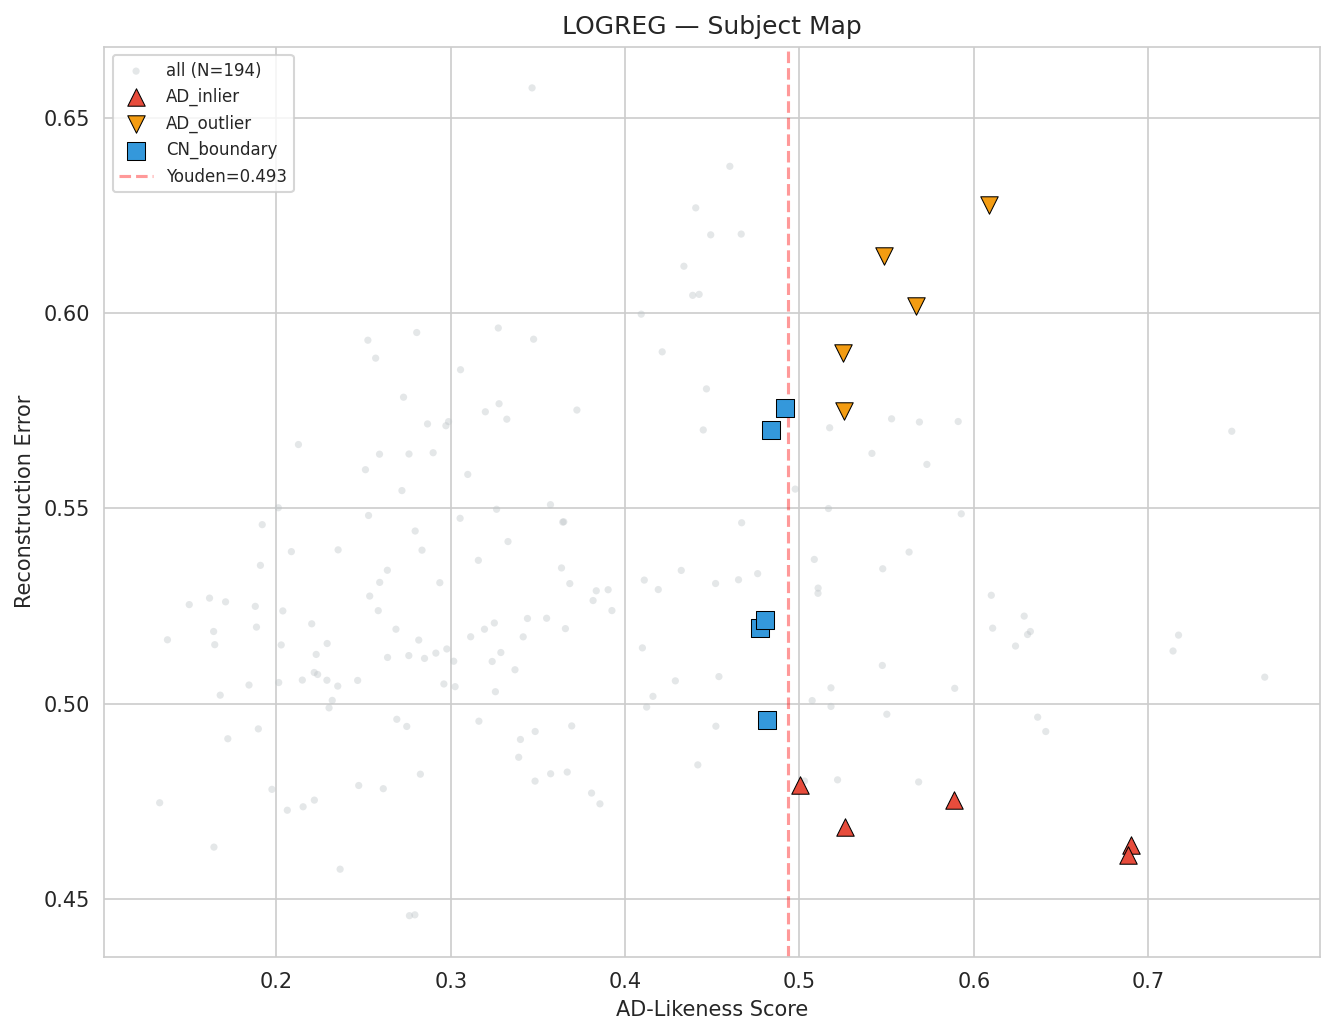

In [17]:
# ═══════════════════════════════════════════════════════════════════════
# §9  SUBJECT SELECTION + clinical annotation
# ═══════════════════════════════════════════════════════════════════════
np.random.seed(SEED_SAMPLING)

for clf in CLASSIFIER_TYPES:
    sub = ensemble[ensemble["classifier"] == clf].copy()
    sub = sub.merge(recon_ens, on="SubjectID", how="left")
    sub = sub.merge(dist_ens, on="SubjectID", how="left")
    sub = sub.merge(sig_df, on="SubjectID", how="left")

    # Use Youden threshold if available, else 0.5
    t_primary = threshold_policies.get("Youden", {}).get("threshold", 0.5)

    # AD-like & in-distribution
    ad_pool = sub[sub["y_score_ensemble"] >= t_primary]
    ad_inlier = ad_pool.nsmallest(TOP_K_SUBJECTS, "recon_error_ensemble")

    # AD-like & OOD
    ad_outlier = ad_pool.nlargest(TOP_K_SUBJECTS, "recon_error_ensemble")

    # CN boundary
    cn_pool = sub[sub["y_score_ensemble"] < t_primary]
    cn_boundary = cn_pool.nlargest(TOP_K_SUBJECTS, "y_score_ensemble")

    display_cols = ["SubjectID", "y_score_ensemble", "y_score_std",
                    "recon_error_ensemble", "S_sig"]
    has_ld = "latent_distance_ensemble" in sub.columns
    if has_ld:
        display_cols.append("latent_distance_ensemble")

    for name, sel in [("AD_inlier", ad_inlier),
                      ("AD_outlier", ad_outlier),
                      ("CN_boundary", cn_boundary)]:
        available = [c for c in display_cols if c in sel.columns]
        print(f"\n{clf.upper()} — {name} (threshold={t_primary:.4f}):")
        print(sel[available].to_string(index=False))

    # Combine + annotate with clinical
    combined = pd.concat([
        ad_inlier.assign(selection="AD_inlier"),
        ad_outlier.assign(selection="AD_outlier"),
        cn_boundary.assign(selection="CN_boundary"),
    ], ignore_index=True)

    # Merge clinical annotation
    combined = combined.merge(
        covid_meta_raw[["_merge_id", "MOCA", "CategoriaFAS", "ResearchGroup"]],
        left_on="SubjectID", right_on="_merge_id", how="left")
    if "_merge_id" in combined.columns:
        combined = combined.drop(columns=["_merge_id"])

    combined.to_csv(TABLES_DIR / f"covid_subject_selection_{clf}.csv", index=False)

    # ── Combined figure ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(sub["y_score_ensemble"], sub["recon_error_ensemble"],
              c="#BDC3C7", s=12, alpha=0.4, edgecolors="none",
              label=f"all (N={len(sub)})")

    sel_colors = {"AD_inlier": "#E74C3C", "AD_outlier": "#F39C12",
                  "CN_boundary": "#3498DB"}
    sel_markers = {"AD_inlier": "^", "AD_outlier": "v", "CN_boundary": "s"}
    for grp, c in sel_colors.items():
        gsel = combined[combined["selection"] == grp]
        gm = sub[sub["SubjectID"].isin(gsel["SubjectID"])]
        ax.scatter(gm["y_score_ensemble"], gm["recon_error_ensemble"],
                  c=c, s=70, marker=sel_markers[grp], edgecolors="black",
                  linewidths=0.5, label=grp, zorder=5)
    ax.axvline(t_primary, color="red", ls="--", alpha=0.4,
               label=f"Youden={t_primary:.3f}")
    ax.set_xlabel("AD-Likeness Score")
    ax.set_ylabel("Reconstruction Error")
    ax.set_title(f"{clf.upper()} — Subject Map")
    ax.legend(fontsize=8, loc="upper left")
    plt.tight_layout()
    save_fig(fig, f"fig9_subject_map_{clf}.png", close=False)
    if SHOW_FIGURES: plt.show()
    else: plt.close()

## Quality Check — Calibration Drift & Sensitivity Analysis

Compare COVID score distribution to ADNI CN and AD out-of-fold
distributions. The COVID scores are **not** diagnostic probabilities —
they are AD-likeness indices.

Sensitivity analysis: repeat key clinical associations under multiple
ADNI-derived thresholds and OOD gating.

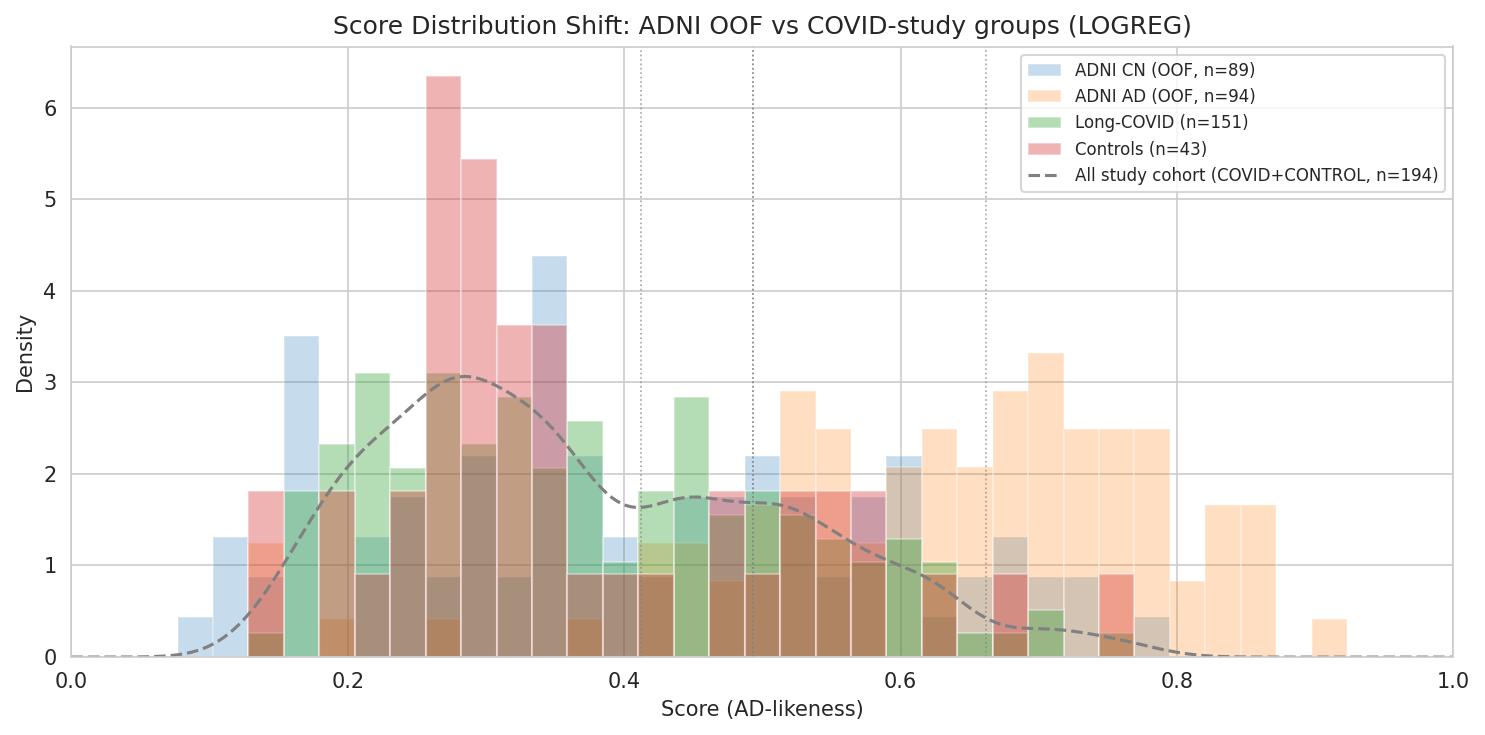


LOGREG — Distribution shift (KS tests):
  KS(Long-COVID, ADNI-CN) = 0.1284, p=2.834e-01
  KS(Long-COVID, ADNI-AD) = 0.6429, p=3.967e-23
  KS(Controls, ADNI-CN) = 0.2211, p=9.714e-02
  KS(Controls, ADNI-AD) = 0.6338, p=9.367e-12
  KS(Long-COVID, Controls) = 0.1446, p=4.366e-01


In [18]:
# QC — Score distribution shift overlay (ADNI OOF vs COVID-study groups)
# Fix: do NOT label COVID (n=194) when it includes CONTROL+COVID.

from scipy.stats import ks_2samp

assert adni_oof_all is not None, "Need ADNI OOF predictions for overlay."

adni_oof = adni_oof_all[adni_oof_all["classifier_type"] == TARGET_CLF].copy()
adni_cn = adni_oof.loc[adni_oof["y_true"] == 0, "y_score_final"].values
adni_ad = adni_oof.loc[adni_oof["y_true"] == 1, "y_score_final"].values

# Build group-aware COVID scores
meta_min = covid_meta_raw[["_merge_id", "ResearchGroup"]].copy()
meta_min["ResearchGroup"] = meta_min["ResearchGroup"].astype(str)

for clf in CLASSIFIER_TYPES:
    sub = ensemble[ensemble["classifier"] == clf].copy()
    sub = sub.merge(meta_min, left_on="SubjectID", right_on="_merge_id", how="left")

    # Defensive: ensure group is present
    if sub["ResearchGroup"].isna().any():
        missing_ids = sub.loc[sub["ResearchGroup"].isna(), "SubjectID"].unique()[:10]
        print(f"⚠ Missing ResearchGroup for {sub['ResearchGroup'].isna().sum()} subjects. Examples: {missing_ids}")

    scores_all = sub["y_score_ensemble"].values
    scores_covid = sub.loc[sub["ResearchGroup"] == "COVID", "y_score_ensemble"].values
    scores_ctrl  = sub.loc[sub["ResearchGroup"] == "CONTROL", "y_score_ensemble"].values

    fig, ax = plt.subplots(figsize=(10, 5))
    bins = np.linspace(0, 1, 40)

    # ADNI references
    ax.hist(adni_cn, bins=bins, alpha=0.25, density=True,
            label=f"ADNI CN (OOF, n={len(adni_cn)})")
    ax.hist(adni_ad, bins=bins, alpha=0.25, density=True,
            label=f"ADNI AD (OOF, n={len(adni_ad)})")

    # COVID-study groups (correct labels)
    ax.hist(scores_covid, bins=bins, alpha=0.35, density=True,
            label=f"Long-COVID (n={len(scores_covid)})")
    ax.hist(scores_ctrl, bins=bins, alpha=0.35, density=True,
            label=f"Controls (n={len(scores_ctrl)})")

    # Optional: total cohort line (NOT called COVID)
    kde_all = gaussian_kde(scores_all, bw_method=0.2)
    xs = np.linspace(0, 1, 300)
    ax.plot(xs, kde_all(xs), color="grey", lw=1.5, ls="--",
            label=f"All study cohort (COVID+CONTROL, n={len(scores_all)})")

    # Threshold markers
    for name, d in threshold_policies.items():
        t = d["threshold"]
        ax.axvline(t, color="grey", ls=":", lw=0.8, alpha=0.7)

    ax.set_xlabel("Score (AD-likeness)")
    ax.set_ylabel("Density")
    ax.set_title(f"Score Distribution Shift: ADNI OOF vs COVID-study groups ({clf.upper()})")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig(fig, f"fig10_score_shift_overlay_{clf}.png", close=False)
    if SHOW_FIGURES: plt.show()
    else: plt.close()

    # KS tests (report separately)
    def _ks(a, b, name_a, name_b):
        ks, p = ks_2samp(a, b)
        print(f"  KS({name_a}, {name_b}) = {ks:.4f}, p={p:.3e}")

    print(f"\n{clf.upper()} — Distribution shift (KS tests):")
    _ks(scores_covid, adni_cn, "Long-COVID", "ADNI-CN")
    _ks(scores_covid, adni_ad, "Long-COVID", "ADNI-AD")
    _ks(scores_ctrl,  adni_cn, "Controls",   "ADNI-CN")
    _ks(scores_ctrl,  adni_ad, "Controls",   "ADNI-AD")
    _ks(scores_covid, scores_ctrl, "Long-COVID", "Controls")

In [19]:
# ═══════════════════════════════════════════════════════════════════════
# QC — Sensitivity analysis: MOCA × threshold on Long-COVID + Controls
#   Primary: Long-COVID only.  Secondary: Study controls (robustness).
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr as _spearmanr_sa

_sens_rows = []

# Resolve cohorts from globals (guard against NameError)
_sa_all = clin_all.copy() if "clin_all" in dir() else _clin_df.copy()
_sa_all["ResearchGroup"] = (
    _sa_all["ResearchGroup"].astype(str).str.strip().str.upper()
)
_sa_covid = _sa_all[_sa_all["ResearchGroup"] == "COVID"].copy()
_sa_ctrl  = _sa_all[_sa_all["ResearchGroup"] == "CONTROL"].copy()

for policy_name, pol in threshold_policies.items():
    thr = pol["threshold"]
    for cohort_label, cohort_df in [("Long-COVID", _sa_covid),
                                     ("Controls", _sa_ctrl),
                                     ("All", _sa_all)]:
        moca_valid = cohort_df[cohort_df["MOCA"].notna()].copy()
        if len(moca_valid) < 10:
            continue
        above = moca_valid[moca_valid["y_score_ensemble"] >= thr]
        below = moca_valid[moca_valid["y_score_ensemble"] < thr]
        r, p = _spearmanr_sa(moca_valid["y_score_ensemble"], moca_valid["MOCA"])
        _sens_rows.append({
            "policy": policy_name, "threshold": thr, "cohort": cohort_label,
            "n_total": len(moca_valid),
            "n_above": len(above), "n_below": len(below),
            "moca_above_median": above["MOCA"].median() if len(above) > 0 else np.nan,
            "moca_below_median": below["MOCA"].median() if len(below) > 0 else np.nan,
            "moca_above_mean": above["MOCA"].mean() if len(above) > 0 else np.nan,
            "moca_below_mean": below["MOCA"].mean() if len(below) > 0 else np.nan,
            "spearman_rho": r, "spearman_p": p,
        })

if _sens_rows:
    _sens_df = pd.DataFrame(_sens_rows)
    # Save combined
    _sens_df.to_csv(TABLES_DIR / "sensitivity_moca_by_threshold.csv", index=False)
    # Save Long-COVID separately
    _sens_covid = _sens_df[_sens_df["cohort"] == "Long-COVID"]
    _sens_covid.to_csv(
        TABLES_DIR / "sensitivity_moca_by_threshold_covid.csv", index=False)
    # Save Controls separately
    _sens_ctrl_df = _sens_df[_sens_df["cohort"] == "Controls"]
    if len(_sens_ctrl_df) > 0:
        _sens_ctrl_df.to_csv(
            TABLES_DIR / "sensitivity_moca_by_threshold_controls.csv", index=False)

    print("Sensitivity Analysis: MOCA by threshold policy\n")
    print("  PRIMARY (Long-COVID only):")
    for _, r in _sens_covid.iterrows():
        above_med = f"{r['moca_above_median']:.1f}" if not np.isnan(r['moca_above_median']) else "n/a"
        below_med = f"{r['moca_below_median']:.1f}" if not np.isnan(r['moca_below_median']) else "n/a"
        print(f"    {r['policy']:12s} (t={r['threshold']:.4f}): "
              f"above n={r['n_above']:3.0f} MOCA median={above_med}, "
              f"below n={r['n_below']:3.0f} MOCA median={below_med}, "
              f"ρ={r['spearman_rho']:.3f}")
    if len(_sens_ctrl_df) > 0:
        print("\n  SECONDARY (Controls — robustness check):")
        for _, r in _sens_ctrl_df.iterrows():
            above_med = f"{r['moca_above_median']:.1f}" if not np.isnan(r['moca_above_median']) else "n/a"
            below_med = f"{r['moca_below_median']:.1f}" if not np.isnan(r['moca_below_median']) else "n/a"
            print(f"    {r['policy']:12s} (t={r['threshold']:.4f}): "
                  f"above n={r['n_above']:3.0f} MOCA median={above_med}, "
                  f"below n={r['n_below']:3.0f} MOCA median={below_med}, "
                  f"ρ={r['spearman_rho']:.3f}")
else:
    print("  ⚠ No data for sensitivity analysis.")

Sensitivity Analysis: MOCA by threshold policy

  PRIMARY (Long-COVID only):
    Youden       (t=0.4935): above n= 35 MOCA median=26.0, below n=116 MOCA median=27.0, ρ=-0.075
    Screening    (t=0.4935): above n= 35 MOCA median=26.0, below n=116 MOCA median=27.0, ρ=-0.075
    FixedFPR     (t=0.6619): above n=  4 MOCA median=26.5, below n=147 MOCA median=26.0, ρ=-0.075
    CostBased    (t=0.4122): above n= 59 MOCA median=26.0, below n= 92 MOCA median=27.0, ρ=-0.075

  SECONDARY (Controls — robustness check):
    Youden       (t=0.4935): above n= 10 MOCA median=26.5, below n= 33 MOCA median=27.0, ρ=0.174
    Screening    (t=0.4935): above n= 10 MOCA median=26.5, below n= 33 MOCA median=27.0, ρ=0.174
    FixedFPR     (t=0.6619): above n=  2 MOCA median=23.5, below n= 41 MOCA median=27.0, ρ=0.174
    CostBased    (t=0.4122): above n= 13 MOCA median=27.0, below n= 30 MOCA median=26.5, ρ=0.174


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# QC — Sensitivity analysis: MOCA × threshold on Long-COVID + Controls
#   Primary: Long-COVID only.  Secondary: Study controls (robustness).
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr as _spearmanr_sa

_sens_rows = []

# Resolve cohorts from globals (guard against NameError)
_sa_all = clin_all.copy() if "clin_all" in dir() else _clin_df.copy()
_sa_all["ResearchGroup"] = (
    _sa_all["ResearchGroup"].astype(str).str.strip().str.upper()
)
_sa_covid = _sa_all[_sa_all["ResearchGroup"] == "COVID"].copy()
_sa_ctrl  = _sa_all[_sa_all["ResearchGroup"] == "CONTROL"].copy()

for policy_name, pol in threshold_policies.items():
    thr = pol["threshold"]
    for cohort_label, cohort_df in [("Long-COVID", _sa_covid),
                                     ("Controls", _sa_ctrl),
                                     ("All", _sa_all)]:
        moca_valid = cohort_df[cohort_df["MOCA"].notna()].copy()
        if len(moca_valid) < 10:
            continue
        above = moca_valid[moca_valid["y_score_ensemble"] >= thr]
        below = moca_valid[moca_valid["y_score_ensemble"] < thr]
        # Spearman: score vs MOCA within cohort
        r, p = _spearmanr_sa(moca_valid["y_score_ensemble"], moca_valid["MOCA"])
        _sens_rows.append({
            "policy": policy_name, "threshold": thr, "cohort": cohort_label,
            "n_total": len(moca_valid),
            "n_above": len(above), "n_below": len(below),
            "moca_above_median": above["MOCA"].median() if len(above) > 0 else np.nan,
            "moca_below_median": below["MOCA"].median() if len(below) > 0 else np.nan,
            "moca_above_mean": above["MOCA"].mean() if len(above) > 0 else np.nan,
            "moca_below_mean": below["MOCA"].mean() if len(above) > 0 else np.nan,
            "spearman_rho": r, "spearman_p": p,
        })

if _sens_rows:
    _sens_df = pd.DataFrame(_sens_rows)
    # Save combined
    _sens_df.to_csv(TABLES_DIR / "sensitivity_moca_by_threshold.csv", index=False)
    # Save Long-COVID separately
    _sens_covid = _sens_df[_sens_df["cohort"] == "Long-COVID"]
    _sens_covid.to_csv(
        TABLES_DIR / "sensitivity_moca_by_threshold_covid.csv", index=False)
    # Save Controls separately
    _sens_ctrl_df = _sens_df[_sens_df["cohort"] == "Controls"]
    if len(_sens_ctrl_df) > 0:
        _sens_ctrl_df.to_csv(
            TABLES_DIR / "sensitivity_moca_by_threshold_controls.csv", index=False)

    print("Sensitivity Analysis: MOCA by threshold policy\n")
    print("  PRIMARY (Long-COVID only):")
    for _, r in _sens_covid.iterrows():
        above_med = f"{r['moca_above_median']:.1f}" if not np.isnan(r['moca_above_median']) else "n/a"
        below_med = f"{r['moca_below_median']:.1f}" if not np.isnan(r['moca_below_median']) else "n/a"
        print(f"    {r['policy']:12s} (t={r['threshold']:.4f}): "
              f"above n={r['n_above']:3.0f} MOCA median={above_med}, "
              f"below n={r['n_below']:3.0f} MOCA median={below_med}, "
              f"ρ={r['spearman_rho']:.3f}")
    if len(_sens_ctrl_df) > 0:
        print("\n  SECONDARY (Controls — robustness check):")
        for _, r in _sens_ctrl_df.iterrows():
            above_med = f"{r['moca_above_median']:.1f}" if not np.isnan(r['moca_above_median']) else "n/a"
            below_med = f"{r['moca_below_median']:.1f}" if not np.isnan(r['moca_below_median']) else "n/a"
            print(f"    {r['policy']:12s} (t={r['threshold']:.4f}): "
                  f"above n={r['n_above']:3.0f} MOCA median={above_med}, "
                  f"below n={r['n_below']:3.0f} MOCA median={below_med}, "
                  f"ρ={r['spearman_rho']:.3f}")
else:
    print("  ⚠ No data for sensitivity analysis.")

Sensitivity Analysis: MOCA by threshold policy

  PRIMARY (Long-COVID only):
    Youden       (t=0.4935): above n= 35 MOCA median=26.0, below n=116 MOCA median=27.0, ρ=-0.075
    Screening    (t=0.4935): above n= 35 MOCA median=26.0, below n=116 MOCA median=27.0, ρ=-0.075
    FixedFPR     (t=0.6619): above n=  4 MOCA median=26.5, below n=147 MOCA median=26.0, ρ=-0.075
    CostBased    (t=0.4122): above n= 59 MOCA median=26.0, below n= 92 MOCA median=27.0, ρ=-0.075

  SECONDARY (Controls — robustness check):
    Youden       (t=0.4935): above n= 10 MOCA median=26.5, below n= 33 MOCA median=27.0, ρ=0.174
    Screening    (t=0.4935): above n= 10 MOCA median=26.5, below n= 33 MOCA median=27.0, ρ=0.174
    FixedFPR     (t=0.6619): above n=  2 MOCA median=23.5, below n= 41 MOCA median=27.0, ρ=0.174
    CostBased    (t=0.4122): above n= 13 MOCA median=27.0, below n= 30 MOCA median=26.5, ρ=0.174


## §F — Outputs Index & Provenance

In [21]:
# ═══════════════════════════════════════════════════════════════════════
# §F  OUTPUTS INDEX + MANIFEST
# ═══════════════════════════════════════════════════════════════════════
# ── Build manifest ───────────────────────────────────────────────
nb_manifest = {
    "created_utc": datetime.datetime.utcnow().isoformat() + "Z",
    "python_version": sys.version,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "project_root": str(PROJECT_ROOT),
    "results_dir": str(RESULTS_DIR),
    "covid_tensor": str(covid_tp),
    "covid_metadata": str(covid_meta_path),
    "n_covid_subjects": int(N_COVID),
    "classifier_types": CLASSIFIER_TYPES,
    "target_clf": TARGET_CLF,
    "threshold_policies": {k: v["threshold"] for k, v in threshold_policies.items()},
    "seed_global": SEED_GLOBAL,
}

# Git hash (best effort)
try:
    git_hash = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=str(PROJECT_ROOT),
        stderr=subprocess.DEVNULL).decode().strip()
    nb_manifest["git_hash"] = git_hash
except Exception:
    nb_manifest["git_hash"] = "unavailable"

manifest_nb_path = OUTPUT_DIR / "notebook_manifest.json"
with open(manifest_nb_path, "w") as f:
    json.dump(nb_manifest, f, indent=2)
print(f"Manifest → {manifest_nb_path}")

# ── Outputs index ────────────────────────────────────────────────
index_rows = []
for subdir in ["Tables", "Figures", "Logs"]:
    d = OUTPUT_DIR / subdir
    if d.exists():
        for fp in sorted(d.iterdir()):
            if fp.is_file():
                index_rows.append({
                    "file": fp.name, "folder": subdir,
                    "size_kb": round(fp.stat().st_size / 1024, 1),
                    "modified": pd.Timestamp(fp.stat().st_mtime, unit="s")
                              .strftime("%Y-%m-%d %H:%M"),
                })
for fp in OUTPUT_DIR.glob("*.json"):
    index_rows.append({
        "file": fp.name, "folder": ".",
        "size_kb": round(fp.stat().st_size / 1024, 1),
        "modified": pd.Timestamp(fp.stat().st_mtime, unit="s")
                  .strftime("%Y-%m-%d %H:%M"),
    })
if index_rows:
    idx_df = pd.DataFrame(index_rows)
    idx_df.to_csv(OUTPUT_DIR / "outputs_index.csv", index=False)
    print(f"\nOutputs index ({len(idx_df)} files):")
    print(idx_df.to_string(index=False))
else:
    print("No outputs found.")

Manifest → /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/inference_covid_paper_output/notebook_manifest.json

Outputs index (34 files):
                                      file  folder  size_kb         modified
               adni_derived_thresholds.csv  Tables      0.3 2026-03-04 20:38
       clinical_analysis_cohort_logreg.csv  Tables     68.1 2026-03-04 20:38
                 clinical_correlations.csv  Tables      0.9 2026-03-04 20:38
            clinical_group_comparisons.csv  Tables      1.9 2026-03-04 20:38
           covid_fold_stability_logreg.csv  Tables     13.9 2026-03-04 20:38
               covid_inference_summary.csv  Tables      0.2 2026-03-04 04:02
        covid_latent_distance_ensemble.csv  Tables      8.4 2026-03-04 03:53
        covid_latent_distance_per_fold.csv  Tables     26.1 2026-03-04 03:53
            covid_ood_quadrants_logreg.csv  Tables     32.7 2026-03-04 20:38
            covid_predictions_ensemble.csv  Tables     18.7 2026-03-04 03:53
 